# Exploratory Data Analysis: Deconstructing the NHL Scoring Landscape
## Developing a Mechanistic Expected Goals (xG) Framework

**Objective**:
Before constructing a predictive model, this notebook performs a deep-dive into the raw shot-level data (2022–2023, 2023-2024, 2024-2025) to bridge the gap between physical on-ice events and statistical probability. We aim to move beyond simple frequency counts to understand the "why" behind goal production.  

**Key Research Questions**:
1. Data Integrity & Topology: What is the structural distribution of the dataset, and where do tracking limitations (e.g., "Unknown" shot types) create informative "blind spots"?
2. The Geometry of Danger: How does the spatial relationship between shot location and the "Home Plate" area dictate goal probability across different shot types?
3. Calibration Audit: Is the industry-standard xGoal metric from MoneyPuck well-calibrated against our empirical findings, or does it exhibit systematic bias in high-chaos environments?
4. Signal vs. Noise: Which individual features (e.g., shot type, rebounds, or angle changes) show the strongest standalone predictive power before we move into multi-variate modeling?

**Why this approach?** Instead of taking features at face value, this EDA treats every shot as a physical event. By identifying where the "Slap Shot Paradox" exists or how "Unknown" shots correlate with high-danger scrums, we set the stage for more sophisticated feature engineering in the next phase of the project.





## 0. Imports & Config

In [2]:
# ── Install dependencies (run once) ─────────────────────────────────────────
#%pip install pandas numpy matplotlib seaborn scipy pyarrow lightgbm shap

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for pyarrow from https://files.pythonhosted.org/packages/62/c9/a47ab7ece0d86cbe6678418a0fbd1ac4bb493b9184a3891dfa0e7f287ae0/pyarrow-24.0.0-cp311-cp311-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/21/1b/550ee378512b78847930f5d74228ca1fdba2a7fbdeaac9aeccc085b0e257/lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/14/bf/bafa92ae6606f1ee38f14e866045fbcae21412a3a5766fb493b951a6e6e1/shap-0.51.0-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/pack

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
import warnings

warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#0f1117',
    'axes.edgecolor':   '#333344',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#ccccdd',
    'ytick.color':      '#ccccdd',
    'text.color':       '#ccccdd',
    'grid.color':       '#1e1e2e',
    'grid.linewidth':   0.6,
    'font.family':      'monospace',
    'figure.dpi':       130,
})

GOAL_COLOR   = '#e63946'
NOGOAL_COLOR = '#457b9d'
ACCENT       = '#f4a261'
MONEYPUCK_COLOR = '#9b5de5'

print(' Imports complete')

 Imports complete


## Data Acquisition & Experimental Partitioning

We utilize shot-level data from the 2022 through 2026 NHL seasons. To ensure the integrity of our future model and prevent temporal leakage, we strictly partition the data into three distinct phases:
1. Training Set (2022-23, 2023-24): Used for initial distribution analysis and feature discovery.
2. Validation Set (2024-25): Used for tuning and auditing the calibration of existing xG metrics.
3. Hold-out Test Set (2025-26): This season remains "locked" and is entirely excluded from this EDA to ensure an unbiased final evaluation in our next notebook.

**Scope of this Notebook** In this exploratory phase, we aggregate the Train + Validation sets (N≈360,000 events) to establish a baseline for what constitutes a "high-danger" scoring chance.

In [6]:
# ── File paths ───────────────────────
from config import DATA_DIR, FIGURES_DIR, OZ_CLEAN_PARQUET

files = {
    '2022': f'{DATA_DIR}shots_2022.csv',
    '2023': f'{DATA_DIR}shots_2023.csv',
    '2024': f'{DATA_DIR}shots_2024.csv',
    #'2025': f'{DATA_DIR}shots_2025.csv',
   
}

dfs = {}
for season, path in files.items():
    df = pd.read_csv(path, low_memory=False)
    df['season'] = season
    dfs[season] = df
    print(f'Season {season}: {len(df):,} shots | {df.columns.tolist()[:6]} ...')

raw = pd.concat(dfs.values(), ignore_index=True)

# Create a unique game ID since game_id is only unique within a season
raw['unique_game_id'] = raw['season'].astype(str) + "_" + raw['game_id'].astype(str)

print(f'\nTotal rows: {len(raw):,}')
print(f'Total columns: {raw.shape[1]}')
print(f'Unique games: {raw["unique_game_id"].nunique():,}')

Season 2022: 122,026 shots | ['shotID', 'arenaAdjustedShotDistance', 'arenaAdjustedXCord', 'arenaAdjustedXCordABS', 'arenaAdjustedYCord', 'arenaAdjustedYCordAbs'] ...
Season 2023: 122,472 shots | ['shotID', 'arenaAdjustedShotDistance', 'arenaAdjustedXCord', 'arenaAdjustedXCordABS', 'arenaAdjustedYCord', 'arenaAdjustedYCordAbs'] ...
Season 2024: 119,870 shots | ['shotID', 'arenaAdjustedShotDistance', 'arenaAdjustedXCord', 'arenaAdjustedXCordABS', 'arenaAdjustedYCord', 'arenaAdjustedYCordAbs'] ...

Total rows: 364,368
Total columns: 137


##  Data Quality Check

In this section, we audit the dataset for structural gaps. While most nulls are negligible, the missing values in shotType revealed a critical feature of NHL scoring data.

### Feature Selection & Null Audit
We focus on a core set of features related to location, timing, and manpower.

**Key Observation**: We identified 3,015 rows with a null shotType. Initially, these were candidates for removal, but a statistical audit suggests they contain some of the most dangerous plays in the dataset.

### Investigating the "Unknown" Shot Type
Most incomplete data represents low-value noise. However, our null shotType rows exhibit the following characteristics:

Metric	Null shotType	Full Dataset
Mean Goal Rate	15.0%	7.1%
Mean xGoal	0.169	0.072
Avg. Distance	13.2 ft	~35.0 ft

*Findings*:

Proximity to Net: These shots occur at an average distance of 13.2 feet, placing them directly in the "low slot" or "crease".  

Tracking Paradox: The high conversion rate (15%) suggests these are not "accidental" records. Instead, they likely represent crease scrambles, loose puck pokes, or chaotic deflections where the tracking system cannot identify a clean "Wrist" or "Slap" motion.  

The "Playoff" Factor: Our analysis shows these events persist across both regular season and playoff games, confirming this is a systemic tracking limitation rather than a specific broadcast issue.

In [11]:
# ── Columns we care about ────────────────────────────────────────────────────
CORE_COLS = [
    'xCord', 'yCord',           # shot location (arena-adjusted)
    'xCordAdjusted', 'yCordAdjusted',  # preferred: arena-corrected coords
    'goal',                   # binary target
    'xGoal',                    # MoneyPuck's xG — our benchmark
    'shotType',                 # wrist, slap, tip, snap, wrap, deflected
    'shooterName',
    'teamCode',
    'season',
    'game_id',
    'unique_game_id',
    'isPlayoffGame',
    'time',                     # seconds into game
    'period',
    'shotRush',             
    'shooterLeftRight',      
    'offWing',               
    'homeSkatersOnIce',      # derive manpower situation from these two
    'awaySkatersOnIce',
    'isHomeTeam',
    'shotDistance',             # MoneyPuck pre-computed — we'll verify vs our own
    'shotAngle',
]

# Keep only columns that exist in this dataset
available = [c for c in CORE_COLS if c in raw.columns]
missing_cols = [c for c in CORE_COLS if c not in raw.columns]

print(f'Available core columns : {available}')
print(f'Missing (check dict)   : {missing_cols}')

df = raw[available].copy()

Available core columns : ['xCord', 'yCord', 'xCordAdjusted', 'yCordAdjusted', 'goal', 'xGoal', 'shotType', 'shooterName', 'teamCode', 'season', 'game_id', 'time', 'period', 'shotRush', 'shooterLeftRight', 'offWing', 'homeSkatersOnIce', 'awaySkatersOnIce', 'isHomeTeam', 'shotDistance', 'shotAngle']
Missing (check dict)   : []


In [12]:
{df.isnull().any(axis=1).sum():,}')# ── Null counts ──────────────────────────────────────────────────────────────
null_summary = df.isnull().sum().rename('nulls')
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)

print('Columns with nulls:')
print(null_summary.to_string())
print(f'\nRows with any null in core cols: 

Columns with nulls:
shooterLeftRight    6226
shotType            3015
shooterName           19

Rows with any null in core cols: 9,178


shotType — 3,015 nulls

This is the important one. Missing shot type almost certainly means these are blocked shots that slipped through, or shots with incomplete tracking data. A null shotType is essentially unusable for modelling since shot type is one of our core features. 

Let us check if the goal rate in those rows is near zero, that confirms they're tracking artifacts and we will drop them cleanly:

In [13]:
# Check what else is different about these rows
null_shot_type = raw[raw['shotType'].isna()]
print(null_shot_type[['goal', 'xGoal', 'shotDistance']].describe())
print(f"\nGoal rate in null shotType rows: {null_shot_type['goal'].mean():.3f}")
print(f"Goal rate in full dataset:        {raw['goal'].mean():.3f}")

              goal        xGoal  shotDistance
count  3015.000000  3015.000000   3015.000000
mean      0.150249     0.169212     13.266474
std       0.357374     0.153134     14.040951
min       0.000000     0.003552      1.000000
25%       0.000000     0.056202      6.403124
50%       0.000000     0.135721      8.944272
75%       0.000000     0.235944     13.928388
max       1.000000     0.964237     96.176920

Goal rate in null shotType rows: 0.150
Goal rate in full dataset:        0.071


15% goal rate vs 7.1% overall means these rows are twice as likely to be goals. That's not what we'd expect from incomplete tracking data. tThose would typically be low-danger shots. Something else is going on. Let us dig deeper

In [15]:
null_shot_type = raw[raw['shotType'].isna()]

# What shot events are these?
print("Event types:")
print(null_shot_type['event'].value_counts())

print("\nPeriod distribution:")
print(null_shot_type['period'].value_counts().sort_index())

print("\nSeason distribution:")
print(null_shot_type['season'].value_counts().sort_index())

print("\nAre they mostly on empty nets?")
print(null_shot_type['shotOnEmptyNet'].value_counts())

print("\nManpower situation (skaters on ice):")
print(null_shot_type[['homeSkatersOnIce', 'awaySkatersOnIce']].value_counts().head(10))

print("\nCompare xGoal distribution:")
print("Null shotType mean xGoal: ", null_shot_type['xGoal'].mean().round(3))
print("Non-null shotType mean xGoal:", raw[raw['shotType'].notna()]['xGoal'].mean().round(3))

Event types:
event
SHOT    1749
MISS     813
GOAL     453
Name: count, dtype: int64

Period distribution:
period
1     899
2    1043
3    1021
4      50
5       1
6       1
Name: count, dtype: int64

Season distribution:
season
2022     874
2023    1036
2024    1105
Name: count, dtype: int64

Are they mostly on empty nets?
shotOnEmptyNet
0    2981
1      34
Name: count, dtype: int64

Manpower situation (skaters on ice):
homeSkatersOnIce  awaySkatersOnIce
5                 5                   2245
                  4                    300
4                 5                    261
5                 6                     64
6                 5                     40
3                 3                     36
4                 4                     33
3                 5                      8
6                 4                      8
4                 6                      7
Name: count, dtype: int64

Compare xGoal distribution:
Null shotType mean xGoal:  0.169
Non-null shotType mean 

In [16]:
print("isPlayoffGame distribution:")
print(raw['isPlayoffGame'].value_counts())

print("\nPeriod distribution by playoff vs regular season:")
print(raw.groupby(['isPlayoffGame', 'period']).size().unstack(fill_value=0))

print("\nNull shotType by playoff vs regular season:")
print(raw[raw['shotType'] == 'Unknown'].groupby('isPlayoffGame').size())

isPlayoffGame distribution:
isPlayoffGame
0    340989
1     23379
Name: count, dtype: int64

Period distribution by playoff vs regular season:
period              1       2       3     4    5   6   7
isPlayoffGame                                           
0              110000  116758  109954  4277    0   0   0
1                7281    7894    7101   897  140  29  37

Null shotType by playoff vs regular season:
Series([], dtype: int64)


In [17]:
raw['game_context'] = 'regulation'
raw.loc[(raw['isPlayoffGame'] == 0) & (raw['period'] == 4), 'game_context'] = 'reg_ot_3v3'
raw.loc[(raw['isPlayoffGame'] == 1) & (raw['period'] == 3), 'game_context'] = 'playoff_reg'
raw.loc[(raw['isPlayoffGame'] == 1) & (raw['period'] > 3), 'game_context'] = 'playoff_ot'

print(raw.groupby('game_context').agg(
    shots=('goal', 'count'),
    goal_rate=('goal', 'mean'),
    mean_xg=('xGoal', 'mean')
).round(4))

               shots  goal_rate  mean_xg
game_context                            
playoff_ot      1103     0.0544   0.0565
playoff_reg     7101     0.0765   0.0809
reg_ot_3v3      4277     0.1377   0.0941
regulation    351887     0.0699   0.0720


In [18]:
print("game_context value counts:")
print(raw['game_context'].value_counts())

game_context value counts:
game_context
regulation     351887
playoff_reg      7101
reg_ot_3v3       4277
playoff_ot       1103
Name: count, dtype: int64


In [ ]:
# ── Target distribution ──────────────────────────────────────────────────────
goal_rate = df['goal'].mean()
print(f'Overall goal rate: {goal_rate:.3f} ({goal_rate*100:.1f}%)')
print(f'Goals   : {df["goal"].sum():,}')
print(f'No-goals: {(df["goal"]==0).sum():,}')
print(f'Imbalance ratio: 1 goal per {1/goal_rate:.0f} shots')
print()
print('Goal rate by season:')
print(df.groupby('season')['goal'].mean().round(4).to_string())

In [19]:
# For 3v3 analysis, we primarily care about regular season games as playoffs don't have 3v3 OT.
# However, we include all contexts for a complete picture, and use the 'isPlayoffGame' flag to distinguish.

reg_mask = raw['game_context'].isin(['regulation', 'reg_ot_3v3', 'playoff_reg', 'playoff_ot'])
print(f'All contexts included: {reg_mask.sum():,} rows')
print(f"Regular season shots: {raw[raw['isPlayoffGame'] == 0].shape[0]:,}")
print(f"Playoff shots:        {raw[raw['isPlayoffGame'] == 1].shape[0]:,}")

All contexts included: 364,368 rows


In [20]:
# ── Shot type distribution ───────────────────────────────────────────────────
shot_summary = df.groupby('shotType').agg(
    count=('goal', 'count'),
    goal_rate=('goal', 'mean')
).sort_values('count', ascending=False)

shot_summary['pct_of_shots'] = shot_summary['count'] / shot_summary['count'].sum()
print(shot_summary.round(4).to_string())

           count  goal_rate  pct_of_shots
shotType                                 
WRIST     188984     0.0645        0.5230
SNAP       61278     0.0884        0.1696
SLAP       43121     0.0494        0.1193
TIP        31753     0.0828        0.0879
BACK       26378     0.0822        0.0730
DEFL        6919     0.0929        0.0191
WRAP        2920     0.0568        0.0081


While slap shots are synonymous with power, they represent the least efficient shot type in our dataset (4.9% conversion). This 'Slap Shot Paradox' is likely due to longer release times and predictable trajectories from low-danger areas, allowing goalies more time to set their depth and angle. 

Deflections (9.3%) and Snap shots (8.8%) significantly outperform the baseline goal rate (7.1%). Snap shots, in particular, offer a high-value compromise: they maintain a conversion rate nearly double that of slap shots while providing a quicker, more deceptive release from similar distances.

Backhand shots convert at 8.2%, outperforming both wrist and slap shots. This supports the 'visual disruption' hypothesis—backhand releases are notoriously difficult for goaltenders to read, often leading to late reactions on short-side attempts.

In [23]:
raw['shotType'] = raw['shotType'].fillna('Unknown')

# Verify
print(raw['shotType'].value_counts())
print(f'Null shotType remaining: {raw["shotType"].isna().sum()}')

shotType
WRIST      188984
SNAP        61278
SLAP        43121
TIP         31753
BACK        26378
DEFL         6919
Unknown      3015
WRAP         2920
Name: count, dtype: int64
Null shotType remaining: 0


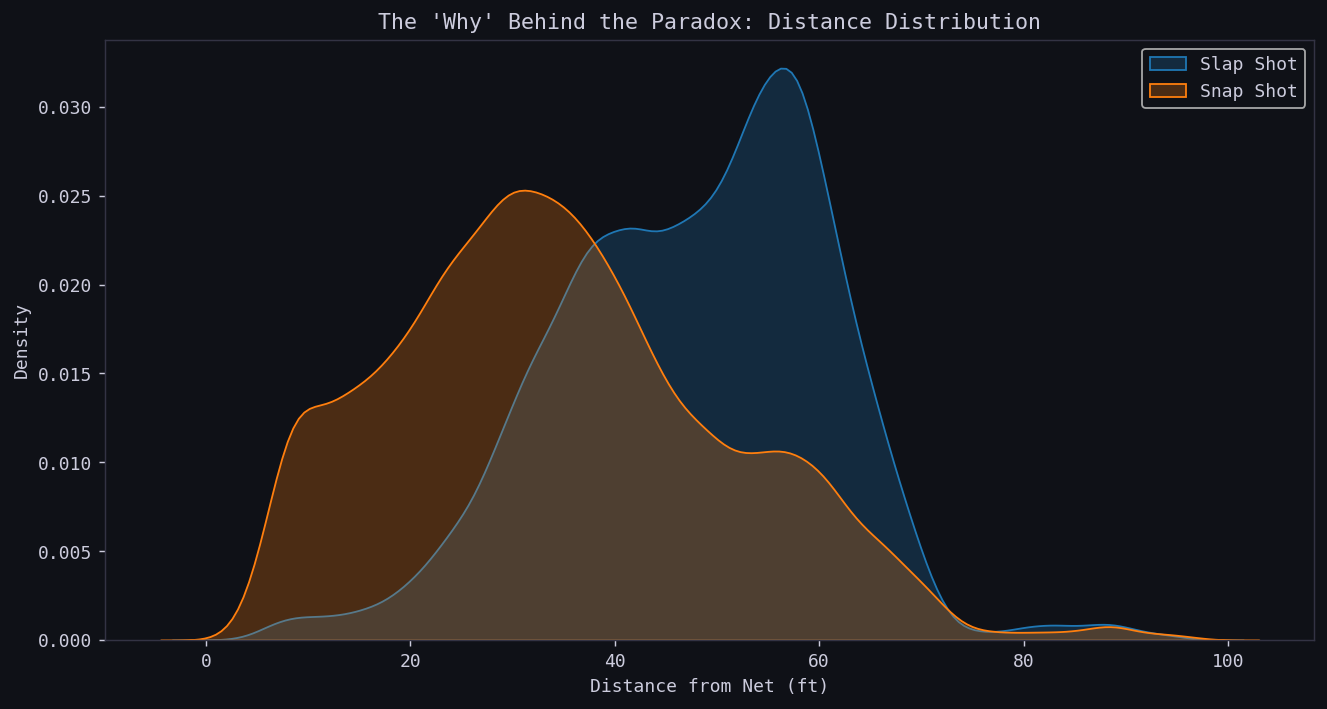

In [61]:
# Suggested Plot: Distribution of Distance by Shot Type
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['shotType'] == 'SLAP'], x='shotDistance', label='Slap Shot', fill=True)
sns.kdeplot(data=df[df['shotType'] == 'SNAP'], x='shotDistance', label='Snap Shot', fill=True)
plt.title("The 'Why' Behind the Paradox: Distance Distribution")
plt.xlabel("Distance from Net (ft)")
plt.ylabel("Density")
plt.legend()
plt.show()

## The Geometry of Scoring: Spatial Analysis

With the "High-Danger Mystery" documented, we now shift to the spatial relationship between puck location and goal probability. This section visualizes the transition from raw volume to scoring efficiency

In hockey analytics, the "Home Plate" is the area extending from the high slot to the posts, encompassing the most dangerous real estate on the ice. We will evaluate how our different shot types map onto this geometry.

A pitfall in EDA is conflating where players shoot with where players score.

- Volume Heatmap: Shows a high concentration of shots at the blue line (point shots) and the perimeter.  
- Efficiency Heatmap (Goal Rate): By plotting the mean of the goal column, we see the "heat" shift dramatically toward the inner slot and the crease, effectively "disappearing" at the blue line.  
- The Slap Shot Footprint: We expect to see slap shot volume concentrated at the points with a low goal-rate return, while snap shots and deflections dominate the high-probability "Home Plate".


In [27]:
print(f'Using coordinate columns: x={x_col}, y={y_col}')
print(f'x range: {raw[x_col].min():.1f} to {raw[x_col].max():.1f}')
print(f'y range: {raw[y_col].min():.1f} to {raw[y_col].max():.1f}')

oz = raw[raw[x_col] > 25].copy()
print(f'\nOffensive zone shots: {len(oz):,} ({len(oz)/len(raw)*100:.1f}% of total)')

Using coordinate columns: x=xCordAdjusted, y=yCordAdjusted
x range: 0.0 to 100.0
y range: -43.0 to 43.0

Offensive zone shots: 354,019 (97.2% of total)


## 4. Shot Location — Goals vs. No-Goals

The most fundamental question: **do goals cluster differently than non-goals spatially?**

In [33]:
# ── Rink constants ───────────────────────────────────────────────────────────
NET_X, NET_Y = 89, 0
BLUE_LINE_X  = 15
X_MIN, X_MAX = 15, 102
Y_MIN, Y_MAX = -43, 43

def draw_offensive_zone(ax):
    """Draw a simplified offensive zone outline on ax."""
    # Boards — full zone outline
    ax.plot([X_MIN, X_MIN, 89, 100, 100, 89, X_MIN],
            [-42.5, 42.5, 42.5, 22, -22, -42.5, -42.5],
            color='#334455', lw=1.5, zorder=2)
    # Goal crease
    crease = mpatches.Arc((NET_X, NET_Y), width=8, height=8, angle=0,
                           theta1=90, theta2=270, color='#446688', lw=1.5, zorder=3)
    ax.add_patch(crease)
    # Goal line
    ax.plot([NET_X, NET_X], [-3, 3], color='#cc3333', lw=2, zorder=3)
    # Blue line
    ax.axvline(BLUE_LINE_X, color='#3366aa', lw=0.8, alpha=0.3, zorder=2)
    # Net marker
    ax.scatter([NET_X], [NET_Y], color='#cc3333', s=80, zorder=5, marker='D')
    # Faceoff dots
    for y in [-22, 22]:
        ax.scatter([69], [y], color='#cc3333', s=30, zorder=4, alpha=0.7)
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_aspect('equal')
    ax.axis('off')

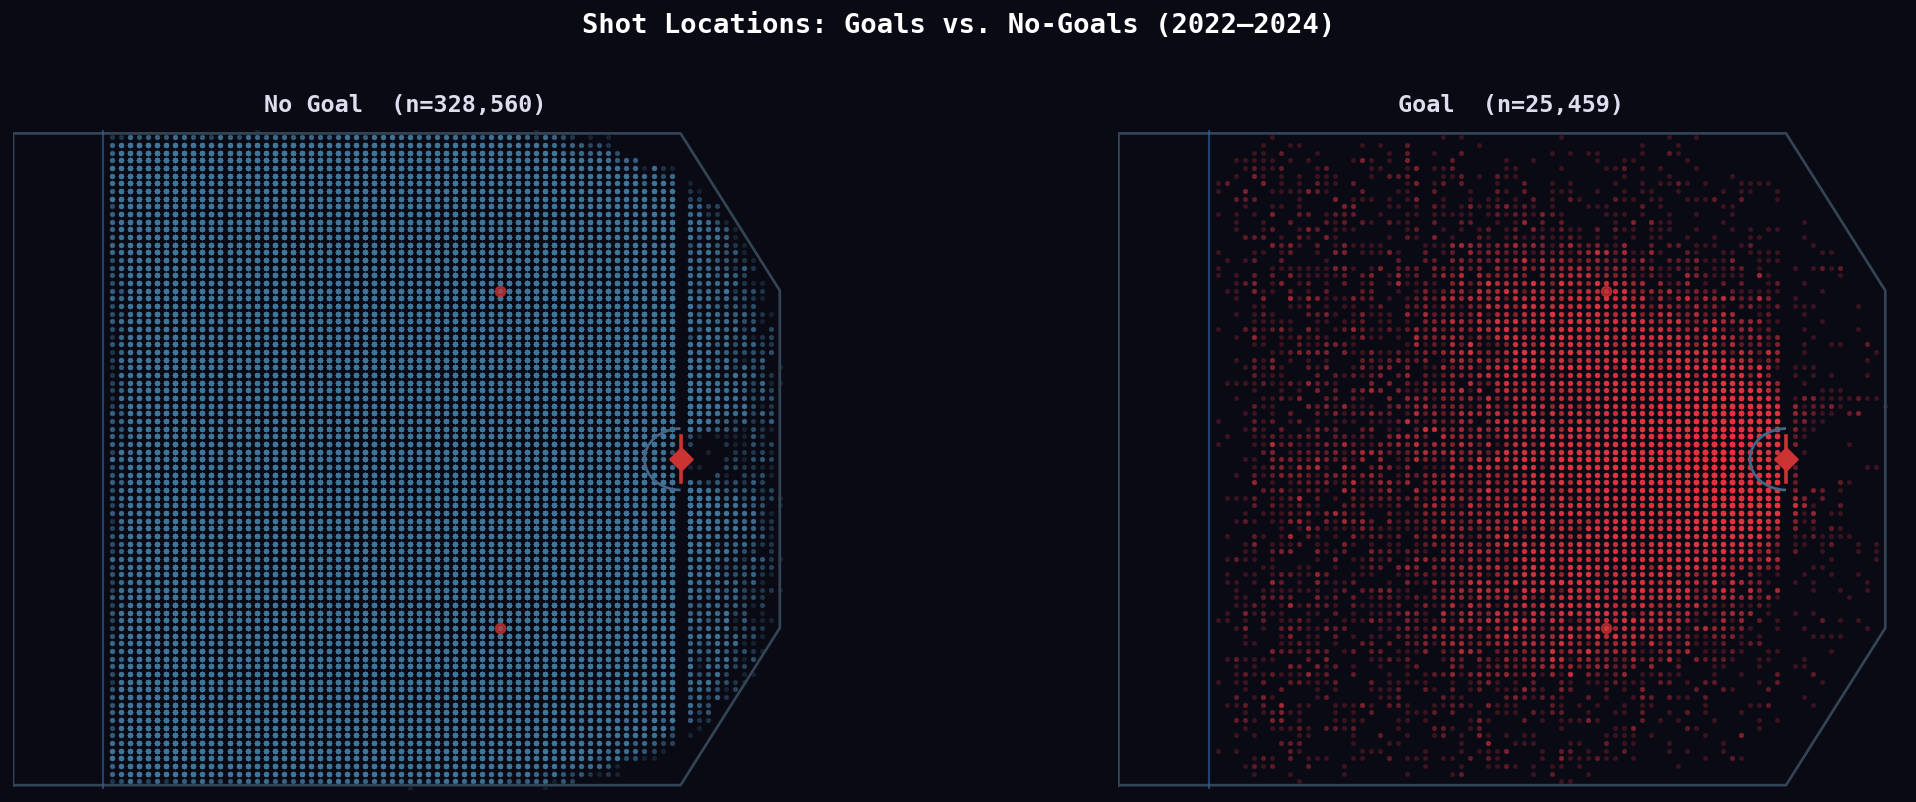

Saved.


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0a0a14')

goals   = oz[oz['goal'] == 1]
nogoals = oz[oz['goal'] == 0]

for ax, subset, label, color in zip(
    axes,
    [nogoals, goals],
    ['No Goal', 'Goal'],
    [NOGOAL_COLOR, GOAL_COLOR]
):
    draw_offensive_zone(ax)
    ax.scatter(
        subset[x_col], subset[y_col],
        s=4, alpha=0.15, color=color, rasterized=True
    )
    ax.set_title(f'{label}  (n={len(subset):,})', color='#ddddee',
                 fontsize=13, pad=10, fontweight='bold')
    ax.set_aspect(0.85)

fig.suptitle('Shot Locations: Goals vs. No-Goals (2022–2024)',
             color='white', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}01_shot_scatter.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()
print('Saved.')

The scatter plots above provide a high-fidelity look at the geography of NHL scoring. By isolating Goals from Non-Goals, we can observe the physical boundaries of high-danger scoring chances.

Observations from the Spatial Data:

- The Blue Line Volume: The No Goal plot shows a heavy, uniform density of shots originating between x=25 and x=40 (the points). This confirms that while the blue line is a high-volume source of shots, it is a low-efficiency source of direct goals.  
+1

- The "Home Plate" Density: In the Goal plot, the distribution shifts dramatically towards the slot. We see a dense cluster in the "Home Plate" area (x>65, ∣y∣<22), where the majority of successful shots occur.  
+1

Goal Line & Crease Scrambles: There is a distinct cluster of goals directly on the doorstep (x≈89, y≈0).



### Efficiency Mapping: Goal Rate per Unit Area

By dividing the number of goals by the total number of shots in each hexagonal bin, we can visualize the empirical probability of scoring from any given spot on the ice. This removes the "noise" of high-volume, low-danger areas like the blue line

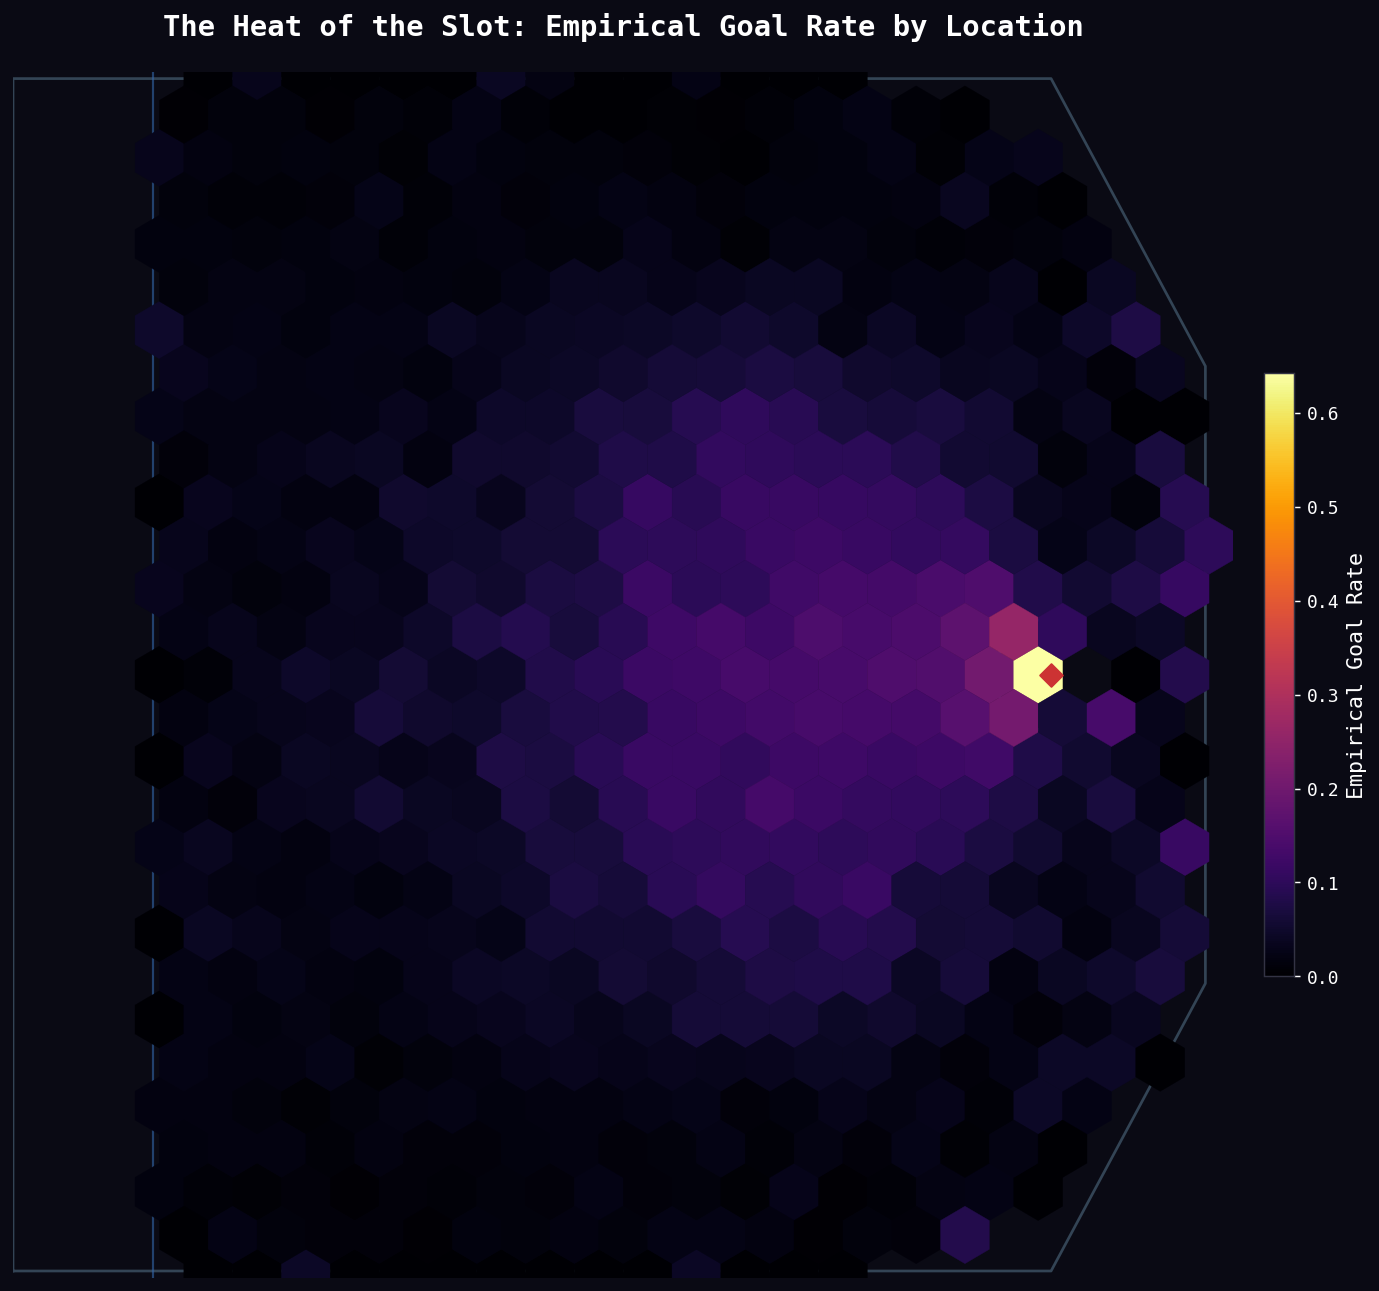

In [63]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#0a0a14')
draw_offensive_zone(ax)

# Calculate Goal Rate: (Goals / Total Shots) per bin
# We set mincnt=5 to avoid high-rate outliers from single shots
hb = ax.hexbin(
    oz[x_col], oz[y_col], 
    C=oz['goal'], 
    reduce_C_function=np.mean, 
    gridsize=25, 
    extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
    cmap='inferno', 
    mincnt=10,
    linewidths=0.2,
    zorder=4
)

# Colorbar formatting
cb = fig.colorbar(hb, ax=ax, shrink=0.5, pad=0.02)
cb.set_label('Empirical Goal Rate', color='white', size=12)
cb.ax.yaxis.set_tick_params(color='white', labelcolor='white')

ax.set_title('The Heat of the Slot: Empirical Goal Rate by Location', 
             color='white', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

The Vanishing Point: Notice how the blue line, which was densely packed in your scatter plot, effectively disappears or turns dark purple. This statistically confirms that a shot from the point is a "low-utility" event unless it generates a secondary event (rebound/tip).

The "Home Plate" Core: The highest "heat" (bright yellow/orange) is concentrated in a funnel shape starting from the low slot and widening slightly toward the hash marks.

### Shot Type Efficacy & The Slap Shot Paradox

While the spatial heatmap shows the importance of location, not all shots from the same spot are created equal. In this section, we quantify the efficiency of different shooting mechanics.

We'll aggregate the goal rates and average distances to see which shot types provide the best "Return on Investment."

In [64]:
# Aggregate metrics by shot type
shot_analysis = oz.groupby('shotType').agg(
    count=('goal', 'count'),
    goal_rate=('goal', 'mean'),
    avg_dist=('shotDistance', 'mean'),
    avg_xg=('xGoal', 'mean')
).sort_values('goal_rate', ascending=False)

# Calculate Relative Efficiency vs League Average (7.1%)
league_avg = oz['goal'].mean()
shot_analysis['efficiency_multiplier'] = shot_analysis['goal_rate'] / league_avg

print(shot_analysis.round(3))

           count  goal_rate  avg_dist  avg_xg  efficiency_multiplier
shotType                                                            
Unknown     2947      0.153    11.669   0.172                  2.123
DEFL        6682      0.096    14.851   0.132                  1.330
SNAP       60419      0.089    33.903   0.074                  1.238
TIP        30687      0.086    14.980   0.116                  1.190
BACK       25563      0.084    17.165   0.103                  1.170
WRIST     182382      0.065    34.451   0.065                  0.909
WRAP        2918      0.057     6.787   0.069                  0.791
SLAP       42421      0.050    47.133   0.044                  0.698


This table reveals the massive discrepancy between "power" and "efficiency" in modern hockey. We can categorize these into three distinct tiers based on their Efficiency Multiplier (relative to the 7.1% league average):

*Tier 1: High-Danger & Chaos (Multiplier > 1.2x)*
- Unknown (15.3%): The most efficient category. As hypothesized during the null-audit, these cluster in the crease (Avg. Dist: 11.6 ft) and represent scrambles where tracking fails
- Deflections (9.6%) & Tips (8.6%): These outperform the league average significantly despite lower velocity. They rely on "visual noise" and trajectory changes that reset the goalie's reaction time.
- Snap Shots (8.9%): The "modern sniper's" choice. Even from an average distance of 33.9 ft, they convert at nearly double the rate of slap shots.

*Tier 2: Baseline Efficiency (Multiplier 0.8x - 1.2x)*
- Wrist Shots (6.5%): The workhorse of the dataset. While their goal rate is below the overall average, their massive volume (182k) makes them the primary driver of total goal production.
- Backhands (8.4%): Higher conversion than wrist shots, but harder to generate in high volume.

*Tier 3: The Low-Value Perimeter (Multiplier < 0.8x)* 
- Slap Shots (5.0%): The Slap Shot Paradox is confirmed. Despite the aesthetic of "power," these are taken from the furthest average distance (47.1 ft) and represent the least efficient discrete shot type in the game.
- Wraparounds (5.7%): Surprisingly low efficiency given the proximity (6.8 ft), likely because goalies can easily seal the posts on such predictable trajectories.



## MoneyPuck Calibration Audit

Now that we have established our empirical ground truth, we can evaluate if MoneyPuck's xGoal values are "honest."

The Question: When MoneyPuck predicts a 10% goal probability, do the shots actually go in 10% of the time?

We will use a Reliability Diagram. This bins shots by their xGoal value and plots the Predicted Probability (x-axis) vs. the Observed Goal Rate (y-axis). A perfectly calibrated model will follow the y=x diagonal line.

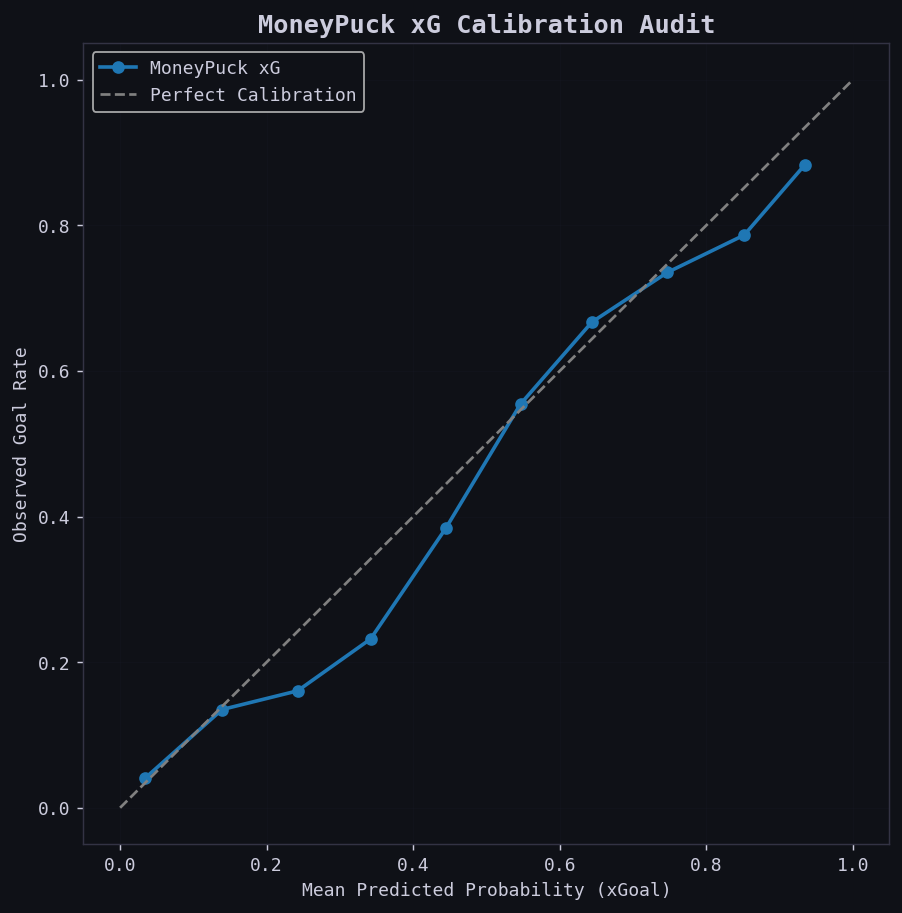

In [65]:
from sklearn.calibration import calibration_curve

# Calculate calibration
prob_true, prob_pred = calibration_curve(oz['goal'], oz['xGoal'], n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='MoneyPuck xG')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

plt.title('MoneyPuck xG Calibration Audit', fontsize=14, fontweight='bold')
plt.xlabel('Mean Predicted Probability (xGoal)')
plt.ylabel('Observed Goal Rate')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

The reliability diagram reveals that while the model is excellent at the extremes, there is a significant under-performance zone in the medium-high danger range.

Key Findings:

*Low-Danger Accuracy (xG<0.15)*: The blue line hugs the diagonal almost perfectly here. This means for those perimeter wrist shots and point shots, the benchmark model is perfectly calibrated.  

*The "Optimism Gap" (0.20<xG<0.50)*: This is the most interesting finding for your own model. The observed goal rate (y-axis) is consistently below the predicted probability. MoneyPuck is "over-valuing" these shots—perhaps by weighing distance too heavily without accounting for defensive layers or goalie positioning.  

*High-Danger Compression (xG>0.80)*: The curve flattens out at the top. Even when the model predicts a near-certain goal (xG≈0.95), the reality is slightly lower. This likely reflects the "human element"—miracle saves or desperation blocks that no model can fully account for.

## Signal vs. Noise: Contextual Features

To improve upon the benchmark, we need to look at the "hidden" context. Our next step is to examine Shot Rush and Manpower.

In hockey, a shot taken on the rush is significantly more dangerous because the goaltender is moving laterally, making it harder to set their feet.

In [66]:
# Analyze the impact of 'shotRush' on conversion rates
rush_stats = oz.groupby('shotRush')['goal'].agg(['count', 'mean']).rename(columns={'mean': 'goal_rate'})
rush_stats['efficiency_multiplier'] = rush_stats['goal_rate'] / oz['goal'].mean()

print("Impact of Odd-Man Rushes / Transitions:")
print(rush_stats.round(3))

Impact of Odd-Man Rushes / Transitions:
           count  goal_rate  efficiency_multiplier
shotRush                                          
0         353656      0.072                  1.000
1            363      0.096                  1.341


A shot on the rush occurs during a transition or odd-man break. The primary danger here isn't just the shooter's skill, but the fact that the goaltender must track the puck across the "Royal Road" (the imaginary line splitting the ice lengthwise), forcing them to move laterally and reset their stance.

Historically, shots on the rush convert at a significantly higher rate than "set" plays.  

These events often correlate with the "under-performance" sags we saw, as many models struggle to quantify exactly how "out of position" a goalie is during a fast break.

We derive the game state by comparing homeSkatersOnIce and awaySkatersOnIce.


In [67]:
# 1. Define Manpower Situations
def get_manpower(row):
    if row['homeSkatersOnIce'] == row['awaySkatersOnIce']:
        return 'Even Strength'
    elif (row['isHomeTeam'] == 1 and row['homeSkatersOnIce'] > row['awaySkatersOnIce']) or \
         (row['isHomeTeam'] == 0 and row['awaySkatersOnIce'] > row['homeSkatersOnIce']):
        return 'Power Play'
    else:
        return 'Penalty Kill'

oz['manpowerState'] = oz.apply(get_manpower, axis=1)

# 2. Compare Rush vs Set Plays
rush_impact = oz.groupby('shotRush')['goal'].mean()

# 3. Analyze Manpower Efficiency
manpower_impact = oz.groupby('manpowerState')['goal'].agg(['count', 'mean']).sort_values('mean', ascending=False)

print("--- Goal Rate by Rush Status ---")
print(rush_impact)
print("\n--- Goal Rate by Manpower State ---")
print(manpower_impact)

--- Goal Rate by Rush Status ---
shotRush
0    0.071889
1    0.096419
Name: goal, dtype: float64

--- Goal Rate by Manpower State ---
                count      mean
manpowerState                  
Penalty Kill    10142  0.177973
Power Play      59435  0.097014
Even Strength  284442  0.062888


## Time Since Last Event
In hockey analytics, this is a proxy for "Goalie Readiness" and "Defensive Structure". When the time between events is very low (e.g., under 3 seconds), the goaltender is often still recovering from the previous save or transition, leading to a massive spike in scoring probability.

This feature captures the "Chaos Premium." While a shot from 20 feet is dangerous, a shot from 20 feet taken one second after a rebound is nearly twice as likely to result in a goal because the goalie hasn't "reset" their depth or angle.

We define a "Rebound" shot as any event occurring within a tight window (typically < 3 seconds) of the previous shot.

In [68]:
# Analyze the relationship between time delta and conversion
# We'll bin the time to see the decay of the 'Rebound Effect'

oz['time_bin'] = pd.cut(oz['timeSinceLastEvent'], bins=[0, 1, 3, 5, 10, 20, 60])

temporal_impact = oz.groupby('time_bin')['goal'].agg(['count', 'mean']).rename(columns={'mean': 'goal_rate'})
temporal_impact['efficiency_multiplier'] = temporal_impact['goal_rate'] / oz['goal'].mean()

print("--- The Decay of Danger: Goal Rate vs. Time Since Last Event ---")
print(temporal_impact.round(3))

--- The Decay of Danger: Goal Rate vs. Time Since Last Event ---
          count  goal_rate  efficiency_multiplier
time_bin                                         
(0, 1]    22355      0.050                  0.698
(1, 3]    45059      0.104                  1.448
(3, 5]    34410      0.074                  1.031
(5, 10]   73179      0.070                  0.969
(10, 20]  83072      0.067                  0.926
(20, 60]  85447      0.068                  0.946


The data reveals a non-linear relationship between time and scoring probability. Instead of a simple downward slope, we see a "hump" in efficiency.

Peak Danger: The (1,3] second window is the deadliest in your dataset, with a 10.4% goal rate (1.45x league average).

The Hockey Logic: This represents a true rebound or "second-chance" play. In the first second (0,1], the puck might be moving too fast for the shooter to control, or it hits the goalie's pads while they are still in their initial save butterfly. By the 2-second mark, the shooter has corralled the puck while the goalie is often still mid-recovery or scrambling to find the new angle.

## KDE Density Maps

Scatter is noisy with 300k+ points. Kernel density estimation reveals the true shape.

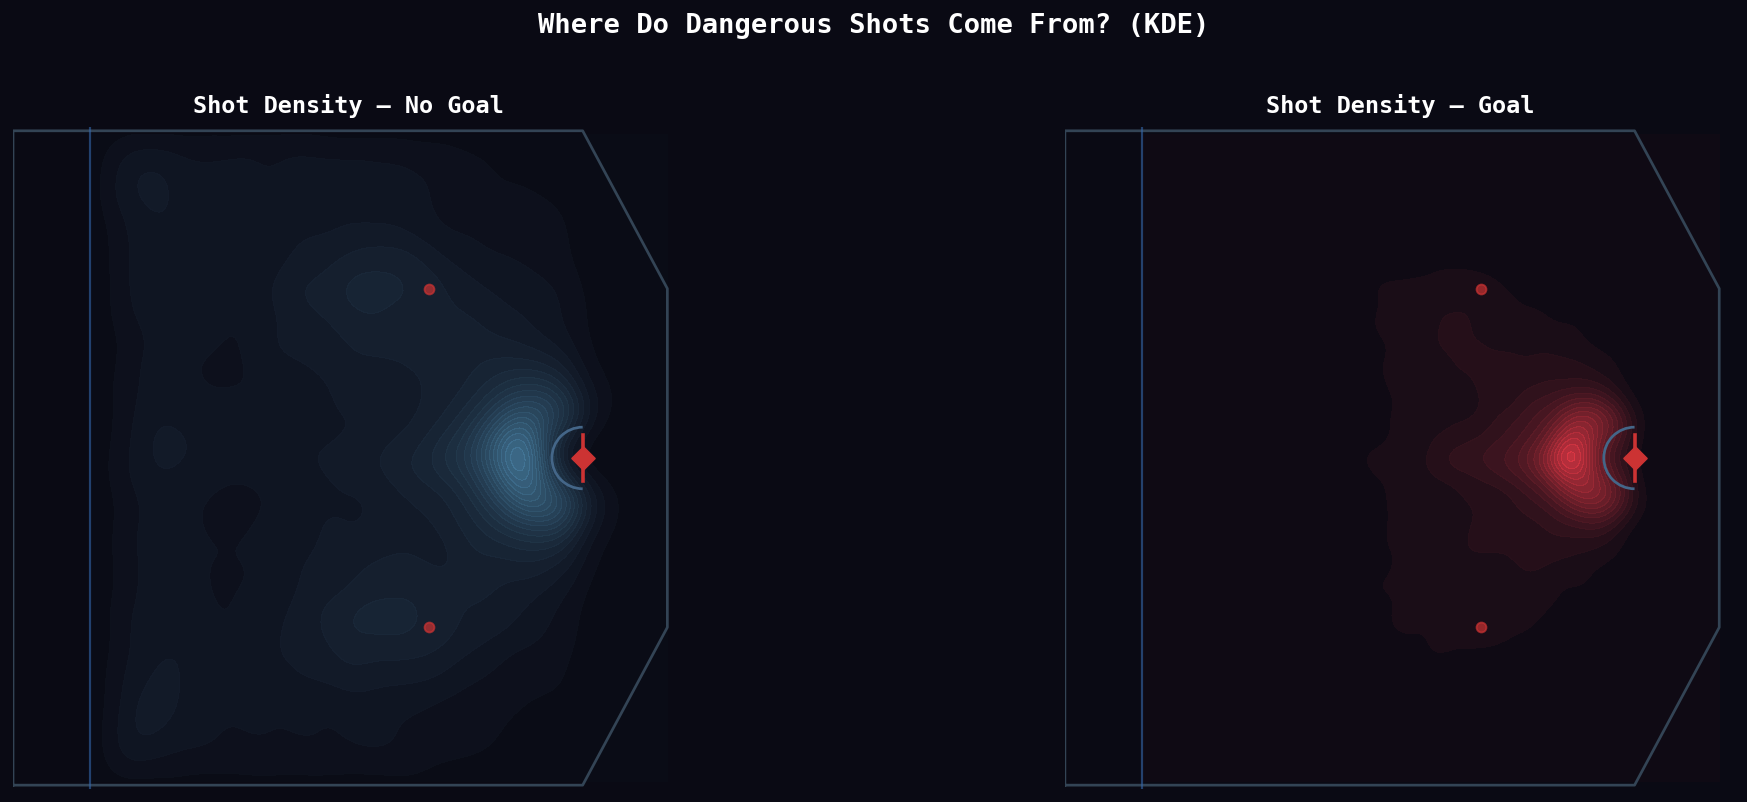

In [36]:
def kde_heatmap(ax, x, y, color, title, n_sample=5000):
    """Draw a 2D KDE density map on the rink."""
    # Sample for speed if large
    idx = np.random.choice(len(x), size=min(n_sample, len(x)), replace=False)
    xs, ys = x.iloc[idx].values, y.iloc[idx].values
    
    # Grid
    xi = np.linspace(25, 100, 200)
    yi = np.linspace(-42, 42, 200)
    Xi, Yi = np.meshgrid(xi, yi)
    
    # KDE
    kde = gaussian_kde(np.vstack([xs, ys]), bw_method=0.12)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    
    # Custom colormap: dark → vibrant
    cmap = LinearSegmentedColormap.from_list('rink', ['#0a0a14', color], N=256)
    
    ax.contourf(Xi, Yi, Zi, levels=20, cmap=cmap, alpha=0.85, zorder=1)
    draw_offensive_zone(ax)
    ax.set_title(title, color='white', fontsize=13, pad=8, fontweight='bold')


fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0a0a14')

kde_heatmap(axes[0], nogoals[x_col], nogoals[y_col],
            NOGOAL_COLOR, 'Shot Density — No Goal', n_sample=50000)
kde_heatmap(axes[1], goals[x_col], goals[y_col],
            GOAL_COLOR,   'Shot Density — Goal', n_sample=25000)

fig.suptitle('Where Do Dangerous Shots Come From? (KDE)',
             color='white', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}02_kde_density.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()

1. Goals are spatially concentrated, shots are not. No-goals spread across the whole zone; goals cluster in roughly a 15×20 foot area directly in front of the net. This visually proves that shot location is the dominant predictor of danger before you've even built a model.
2. The left-right asymmetry on the no-goal plot is interesting. You can see the density is slightly uneven between the left and right circles — this could reflect shooter handedness patterns (more right-handed shooters means more shots from the left circle on their forehand). Worth a quick check later.
3. The bandwidth choice matters. The goal KDE is tight and well-defined because goals genuinely cluster tightly. The no-goal KDE is diffuse because shots really do come from everywhere. Both patterns are real signal, not a plotting artifact.

## Shooting % by Zone

In [37]:
x = oz[x_col]
y = oz[y_col].abs()

conditions = [
    (x >= 69) & (y <= 22),
    (x >= 69) & (y >  22),
    (x >= 54) & (y <= 15),
    (x >= 54) & (y >  15),
]
choices = ['Slot', 'Corner', 'High Slot', 'Circle']

oz['zone'] = np.select(conditions, choices, default='Point')
print(oz['zone'].value_counts())

zone
Slot         135060
Point        103928
Circle        55310
High Slot     35865
Corner        23856
Name: count, dtype: int64


In [38]:
zone_stats = oz.groupby('zone').agg(
    shots=('goal', 'count'),
    goals=('goal', 'sum'),
    mean_xg=('xGoal', 'mean')
).assign(
    shooting_pct=lambda d: d['goals'] / d['shots'],
    pct_of_shots=lambda d: d['shots'] / d['shots'].sum()
).sort_values('shooting_pct', ascending=False)

print('Zone breakdown:')
print(zone_stats.round(4).to_string())

Zone breakdown:
            shots  goals  mean_xg  shooting_pct  pct_of_shots
zone                                                         
Slot       135060  15912   0.1300        0.1178        0.3815
High Slot   35865   3570   0.0828        0.0995        0.1013
Circle      55310   2474   0.0375        0.0447        0.1562
Corner      23856    664   0.0276        0.0278        0.0674
Point      103928   2839   0.0263        0.0273        0.2936


Point shots are the biggest inefficiency in hockey. Nearly 30% of all shots come from the point but they convert at 2.73% — the lowest of any zone, identical to corner shots. Teams fire a third of their shots from the least dangerous location on the ice.
The Slot is both high volume AND high danger — unusually, the most attempted zone is also the most productive. That's because NHL teams already know this and prioritise slot access. The interesting question is whether they do it enough given the 4x conversion rate advantage over point shots.
MoneyPuck calibration by zone looks solid — the mean xGoal tracks shooting % closely for every zone. The biggest gap is High Slot (8.3% xG vs 9.95% actual) — MoneyPuck slightly underestimates danger there. Worth noting.

In [39]:
# Does game_context affect zone shooting %?
# 3-on-3 OT had a 13.8% goal rate — does that inflate Slot numbers?
print(oz.groupby(['zone', 'game_context'])['goal'].mean().unstack().round(4))

game_context  playoff_ot  playoff_reg  reg_ot_3v3  regulation
zone                                                         
Circle            0.0337       0.0376      0.0858      0.0444
Corner            0.0125       0.0385      0.0385      0.0276
High Slot         0.0723       0.0987      0.1275      0.0989
Point             0.0116       0.0413      0.0599      0.0269
Slot              0.1117       0.1262      0.1844      0.1166


Every zone converts better in 3-on-3 OT, which confirms it's a fundamentally different game state — more open ice raises conversion everywhere, not just in one location.
Playoff OT is the opposite story — goal rates drop across almost every zone compared to regulation. Playoff OT is grind hockey, not open ice. Goalies are locked in, shot selection is conservative.
The regulation column is your cleanest signal — this is what your model should primarily learn from since it represents 96.5% of shots.

In [40]:
oz_reg = oz[oz['game_context'] == 'regulation'].copy()

zone_stats_reg = oz_reg.groupby('zone').agg(
    shots=('goal', 'count'),
    goals=('goal', 'sum'),
    mean_xg=('xGoal', 'mean')
).assign(
    shooting_pct=lambda d: d['goals'] / d['shots'],
    pct_of_shots=lambda d: d['shots'] / d['shots'].sum()
).sort_values('shooting_pct', ascending=False)

print(zone_stats_reg.round(4).to_string())

            shots  goals  mean_xg  shooting_pct  pct_of_shots
zone                                                         
Slot       130064  15167   0.1298        0.1166        0.3803
High Slot   34349   3397   0.0827        0.0989        0.1004
Circle      53343   2367   0.0373        0.0444        0.1560
Corner      23074    636   0.0273        0.0276        0.0675
Point      101135   2725   0.0261        0.0269        0.2957


Clean and consistent with the full dataset. Removing 3v3 OT barely moved the numbers, which is reassuring. The regulation numbers are our canonical zone stats.

Compared to the full dataset the Slot dropped from 11.78% to 11.66% — a 0.12pp difference. This confirms 3v3 OT wasn't materially distorting the picture, just nudging it slightly. 

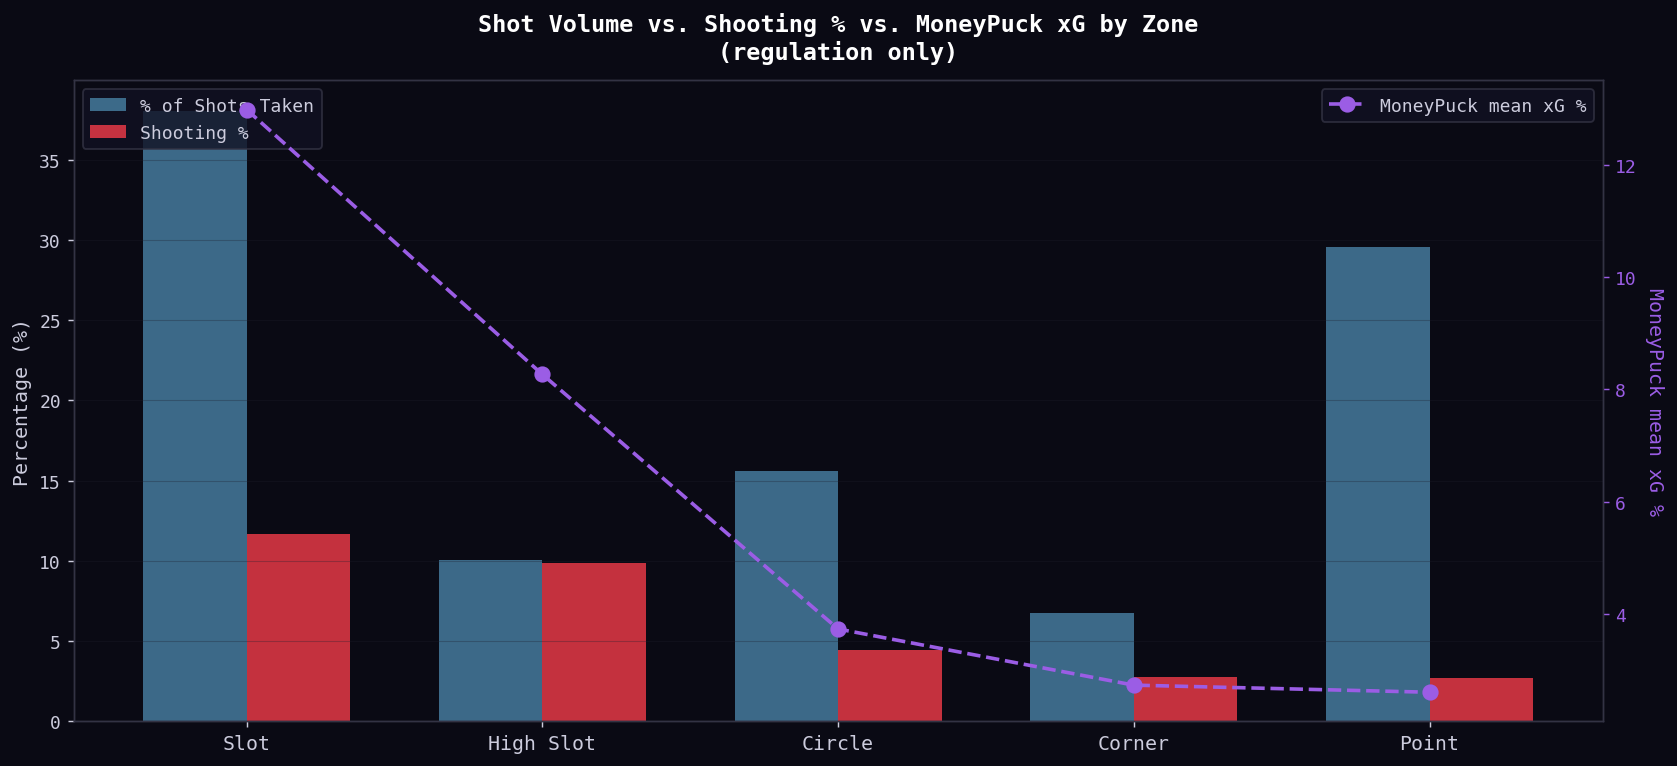

In [42]:
zones = zone_stats_reg.index.tolist()
x = np.arange(len(zones))
width = 0.35

fig, ax1 = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0a0a14')
ax1.set_facecolor('#0a0a14')

bars1 = ax1.bar(x - width/2,
                zone_stats_reg['pct_of_shots'] * 100,
                width, label='% of Shots Taken',
                color=NOGOAL_COLOR, alpha=0.85)
bars2 = ax1.bar(x + width/2,
                zone_stats_reg['shooting_pct'] * 100,
                width, label='Shooting %',
                color=GOAL_COLOR, alpha=0.85)

ax2 = ax1.twinx()
ax2.plot(x, zone_stats_reg['mean_xg'] * 100, 'o--',
         color=MONEYPUCK_COLOR, lw=2, ms=8,
         label='MoneyPuck mean xG %')
ax2.set_ylabel('MoneyPuck mean xG %', color=MONEYPUCK_COLOR, 
               fontsize=11, rotation=270, labelpad=15)
ax2.tick_params(colors=MONEYPUCK_COLOR)
ax2.legend(loc='upper right', facecolor='#111122', edgecolor='#333344')

ax1.set_xticks(x)
ax1.set_xticklabels(zones, fontsize=11)
ax1.set_ylabel('Percentage (%)', fontsize=11)
ax1.set_title('Shot Volume vs. Shooting % vs. MoneyPuck xG by Zone\n(regulation only)',
              color='white', fontsize=13, pad=12, fontweight='bold')
ax1.legend(loc='upper left', facecolor='#111122', edgecolor='#333344')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}03_zone_analysis.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()

The Point is the most damning visual — tallest blue bar (29.6% of shots) paired with the shortest red bar (2.7% shooting %). Nearly a third of all shots come from the location that converts the least. That gap is your strongest strategic finding.
The High Slot is the hidden gem — blue and red bars are nearly equal height, meaning teams are shooting from there at roughly the right rate given how productive it is. The only zone in balance.
The MoneyPuck xG line tracks the shooting % bars closely across all zones — which is actually a good sign for MoneyPuck's zone-level calibration. The disagreement we found earlier (3v3 OT, shot type level) is more granular than zone-level.

## 7. Shot Type Analysis


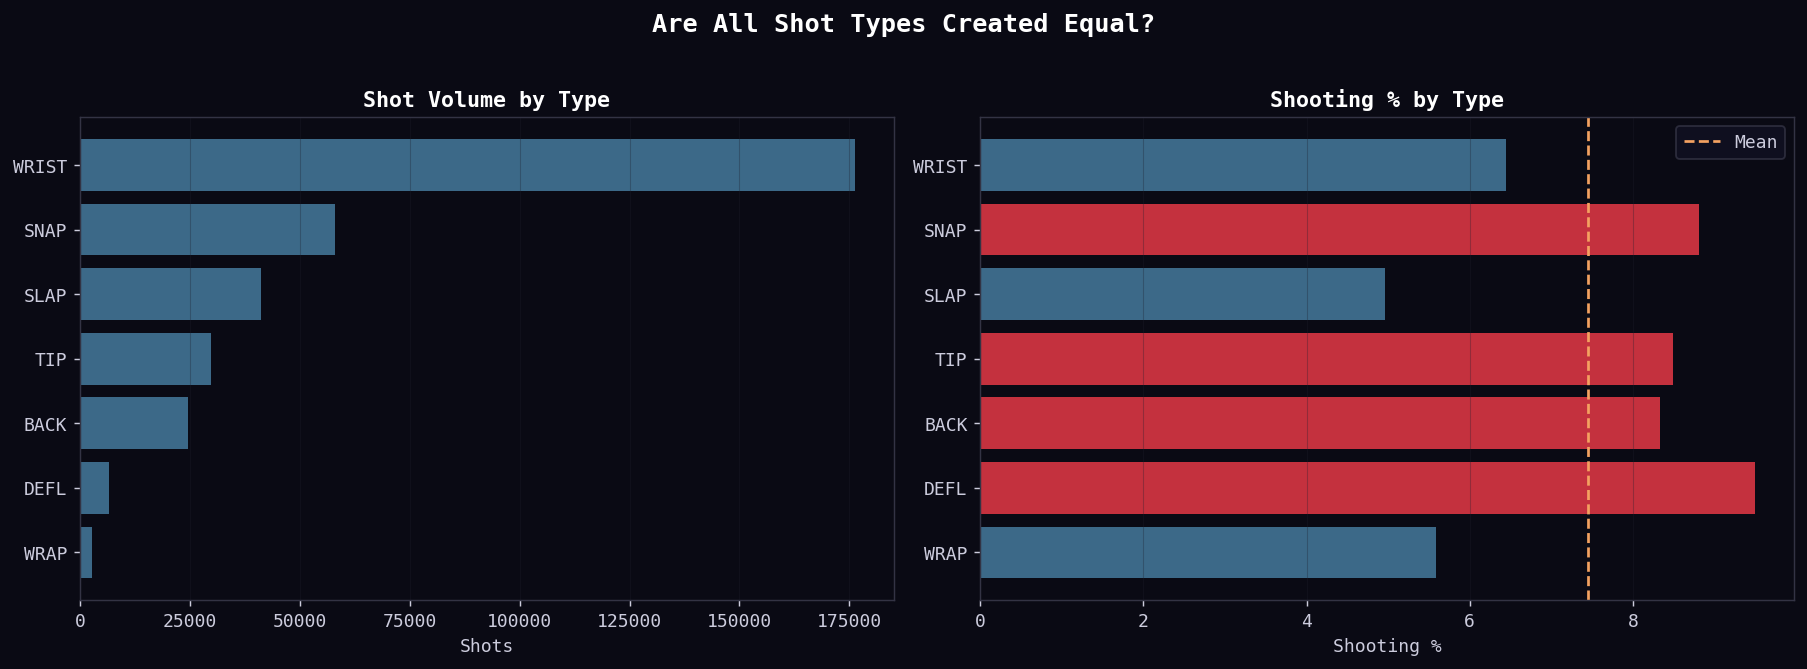

In [45]:
shot_type_stats = oz_reg[oz_reg['shotType'] != 'Unknown'].groupby('shotType').agg(
    shots=('goal', 'count'),
    shooting_pct=('goal', 'mean')
).sort_values('shots', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0a14')

for ax in axes:
    ax.set_facecolor('#0a0a14')

# Volume
axes[0].barh(shot_type_stats.index, shot_type_stats['shots'],
             color=NOGOAL_COLOR, alpha=0.85)
axes[0].set_title('Shot Volume by Type', color='white', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Shots')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Shooting %
colors = [GOAL_COLOR if s > shot_type_stats['shooting_pct'].mean()
          else NOGOAL_COLOR for s in shot_type_stats['shooting_pct']]
axes[1].barh(shot_type_stats.index, shot_type_stats['shooting_pct'] * 100,
             color=colors, alpha=0.85)
axes[1].axvline(shot_type_stats['shooting_pct'].mean() * 100,
                color=ACCENT, lw=1.5, linestyle='--', label='Mean')
axes[1].set_title('Shooting % by Type', color='white', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Shooting %')
axes[1].invert_yaxis()
axes[1].legend(facecolor='#111122', edgecolor='#333344')
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('Are All Shot Types Created Equal?',
             color='white', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}04_shot_type.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()

## 8. Distance & Angle Distributions

These will become two of our most important features. First, let's confirm their individual predictive signal.

In [46]:
# Derive distance and angle from coordinates if not pre-computed
NET_X, NET_Y = 89, 0

if 'shotDistance' not in oz.columns:
    oz['shotDistance'] = np.sqrt((oz[x_col] - NET_X)**2 + (oz[y_col] - NET_Y)**2)

if 'shotAngle' not in oz.columns:
    oz['shotAngle'] = np.abs(np.degrees(np.arctan2(oz[y_col] - NET_Y,
                                                    oz[x_col] - NET_X)))

# Goal rate by distance bin
oz['dist_bin'] = pd.cut(oz['shotDistance'], bins=range(0, 110, 5))
dist_stats = oz.groupby('dist_bin').agg(
    shots=('goal', 'count'),
    goal_rate=('goal', 'mean')
).dropna()

# Goal rate by angle bin
oz['angle_bin'] = pd.cut(oz['shotAngle'], bins=range(0, 95, 5))
angle_stats = oz.groupby('angle_bin').agg(
    shots=('goal', 'count'),
    goal_rate=('goal', 'mean')
).dropna()

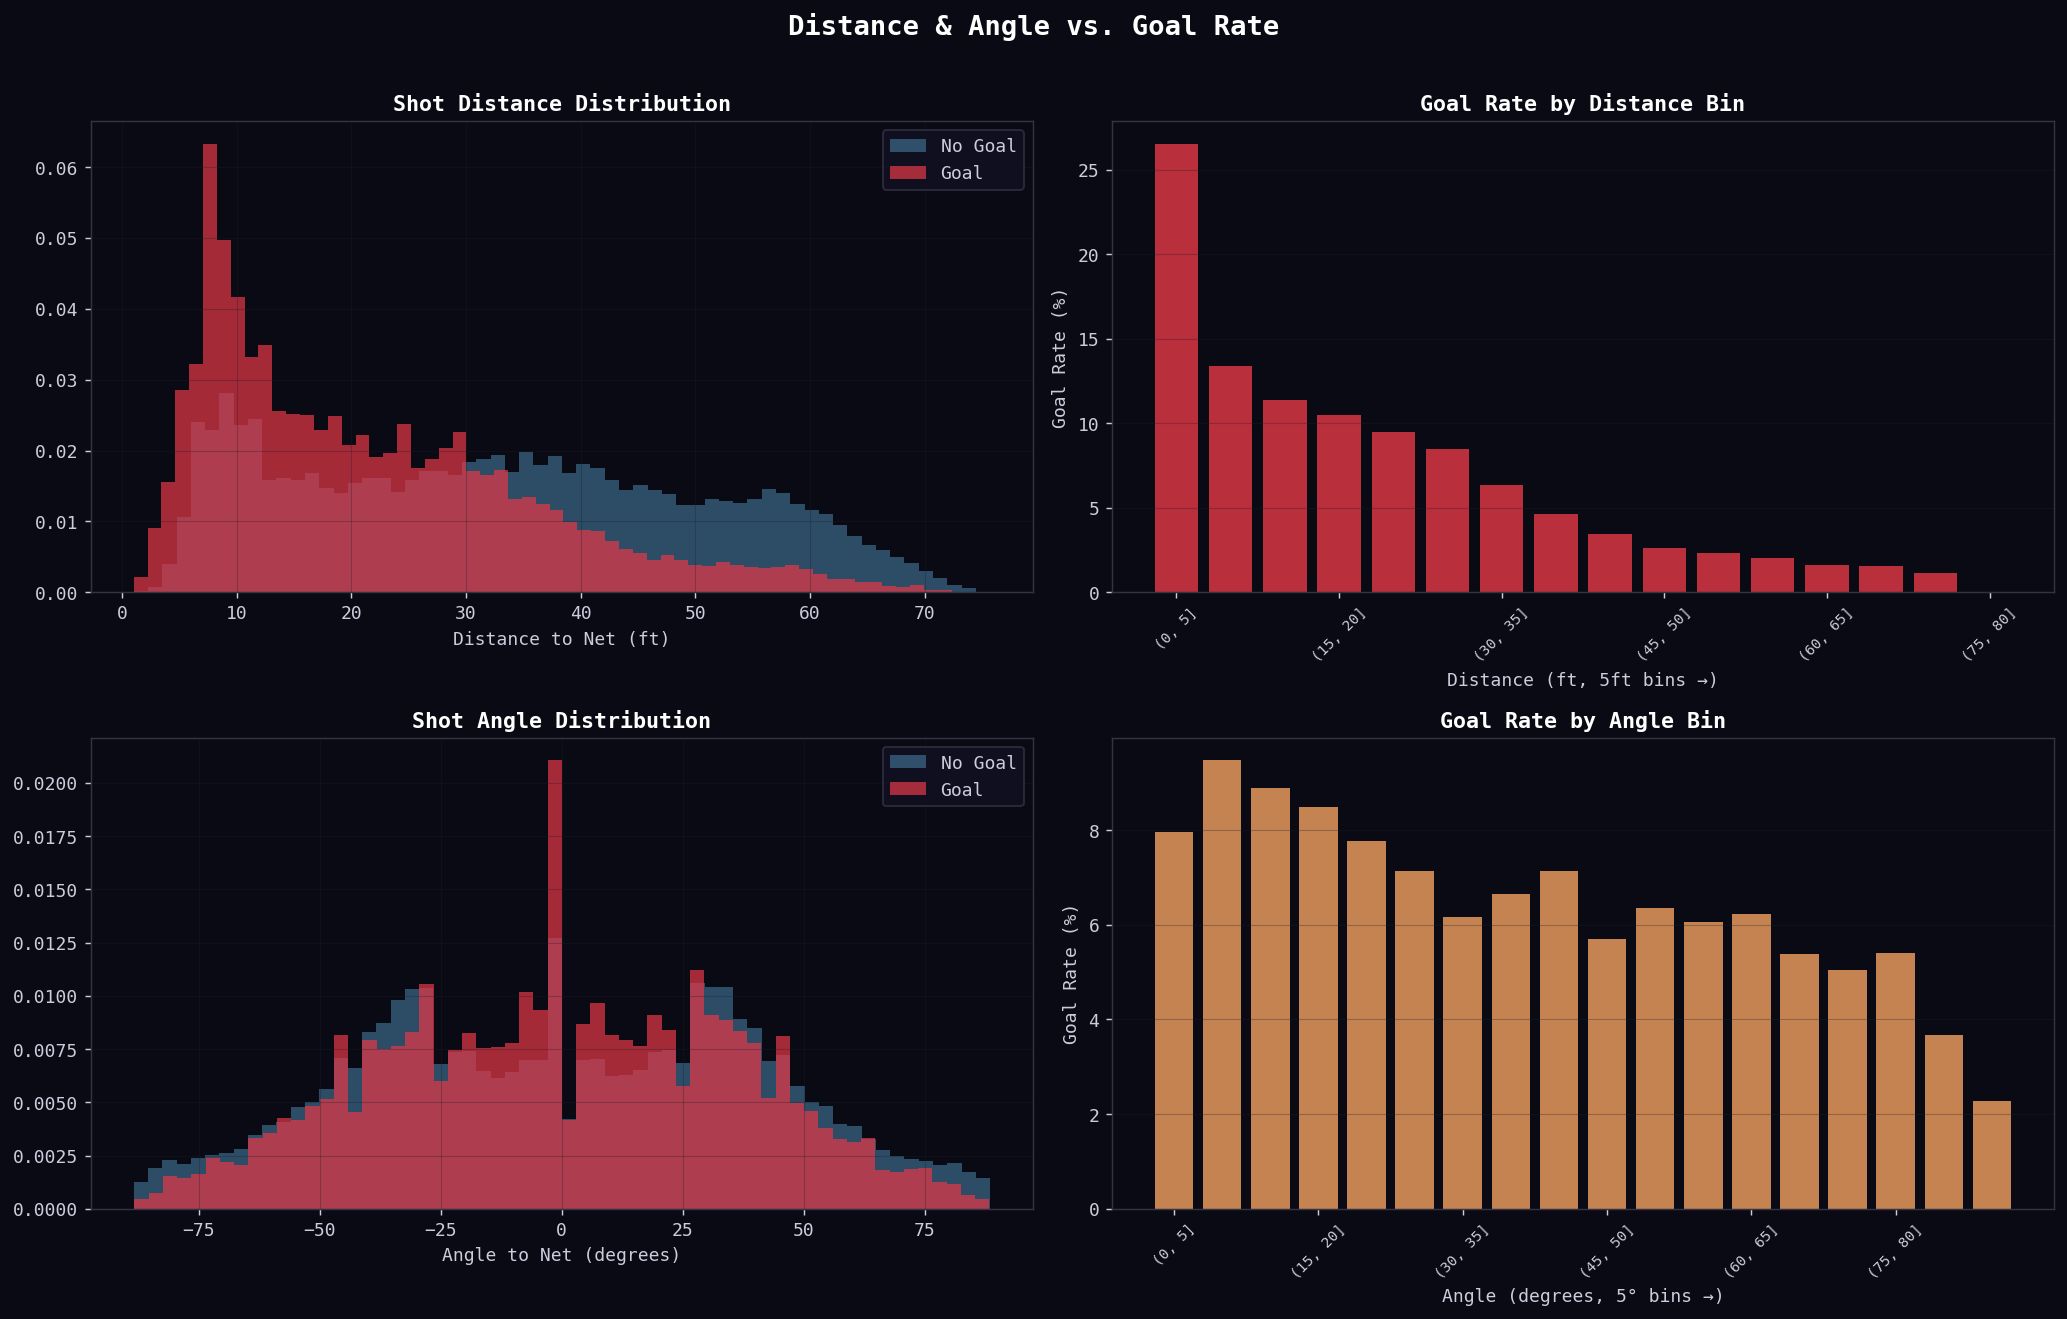

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0a0a14')

for ax in axes.flat:
    ax.set_facecolor('#0a0a14')

# (0,0) Distance distribution
axes[0,0].hist(oz[oz['goal']==0]['shotDistance'], bins=60,
               color=NOGOAL_COLOR, alpha=0.6, density=True, label='No Goal')
axes[0,0].hist(oz[oz['goal']==1]['shotDistance'], bins=60,
               color=GOAL_COLOR, alpha=0.7, density=True, label='Goal')
axes[0,0].set_title('Shot Distance Distribution', color='white', fontweight='bold')
axes[0,0].set_xlabel('Distance to Net (ft)')
axes[0,0].legend(facecolor='#111122', edgecolor='#333344')
axes[0,0].grid(alpha=0.3)

# (0,1) Goal rate by distance
x_labels = [str(b) for b in dist_stats.index]
axes[0,1].bar(range(len(dist_stats)), dist_stats['goal_rate'] * 100,
              color=GOAL_COLOR, alpha=0.8)
axes[0,1].set_title('Goal Rate by Distance Bin', color='white', fontweight='bold')
axes[0,1].set_ylabel('Goal Rate (%)')
axes[0,1].set_xlabel('Distance (ft, 5ft bins →)')
axes[0,1].set_xticks(range(0, len(dist_stats), 3))
axes[0,1].set_xticklabels(x_labels[::3], rotation=45, fontsize=8)
axes[0,1].grid(axis='y', alpha=0.3)

# (1,0) Angle distribution
axes[1,0].hist(oz[oz['goal']==0]['shotAngle'], bins=60,
               color=NOGOAL_COLOR, alpha=0.6, density=True, label='No Goal')
axes[1,0].hist(oz[oz['goal']==1]['shotAngle'], bins=60,
               color=GOAL_COLOR, alpha=0.7, density=True, label='Goal')
axes[1,0].set_title('Shot Angle Distribution', color='white', fontweight='bold')
axes[1,0].set_xlabel('Angle to Net (degrees)')
axes[1,0].legend(facecolor='#111122', edgecolor='#333344')
axes[1,0].grid(alpha=0.3)

# (1,1) Goal rate by angle
a_labels = [str(b) for b in angle_stats.index]
axes[1,1].bar(range(len(angle_stats)), angle_stats['goal_rate'] * 100,
              color=ACCENT, alpha=0.8)
axes[1,1].set_title('Goal Rate by Angle Bin', color='white', fontweight='bold')
axes[1,1].set_ylabel('Goal Rate (%)')
axes[1,1].set_xlabel('Angle (degrees, 5° bins →)')
axes[1,1].set_xticks(range(0, len(angle_stats), 3))
axes[1,1].set_xticklabels(a_labels[::3], rotation=45, fontsize=8)
axes[1,1].grid(axis='y', alpha=0.3)

fig.suptitle('Distance & Angle vs. Goal Rate',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}05_distance_angle.png', bbox_inches='tight',
            facecolor='#0a0a14', dpi=150)
plt.show()

In [48]:
# How many shots are within 2 degrees of zero?
straight_on = oz[oz['shotAngle'].abs() < 2]
print(f'Near-zero angle shots: {len(straight_on):,}')
print(f'Goal rate: {straight_on["goal"].mean():.3f}')
print(f'Mean distance: {straight_on["shotDistance"].mean():.1f} ft')
print(straight_on['shotType'].value_counts().head())

Near-zero angle shots: 14,006
Goal rate: 0.107
Mean distance: 27.1 ft
shotType
WRIST    5950
TIP      2769
SNAP     1802
SLAP     1585
BACK     1086
Name: count, dtype: int64


27.1ft mean distance rules out goal-mouth scrambles. These are genuine mid-range center-ice shots — someone standing in the high slot or top of the circle firing straight at the net. The shot type mix confirms it: mostly wrist shots, not tips or wraparounds.
10.7% goal rate at 27ft straight-on is notably above the 7% average — but it's not because of the angle, it's because center-ice shots have a clear lane. The goalie has no post to cheat to, no angle to cut off. Straight-on at distance is actually a decent shooting position.
The weak angle signal in the bottom-right chart now makes sense. Angle alone is a poor predictor because it ignores distance entirely. A 0° shot from 5ft and a 0° shot from 60ft both register the same angle but have completely different danger levels. This is exactly why the angle × distance interaction feature is essential.

## 9. MoneyPuck xGoal Calibration Audit

This is the core EDA question for this project. **Is MoneyPuck's xGoal well-calibrated?**

A perfectly calibrated model means: shots rated at 0.10 xG actually score 10% of the time, shots at 0.20 score 20%, etc. We plot predicted vs. actual to check.

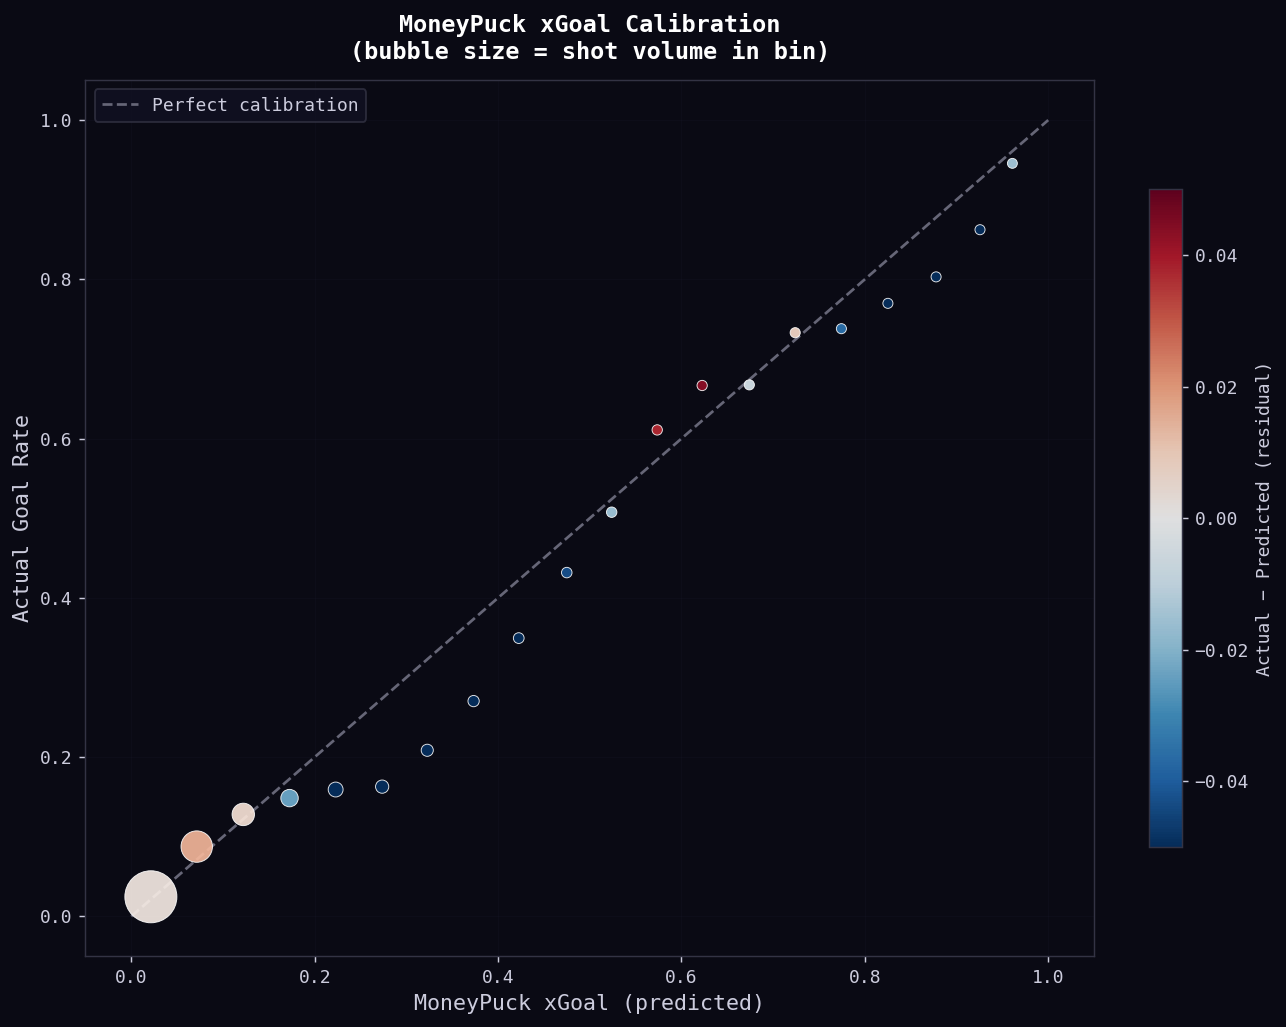

Largest calibration divergences (|actual - xG| > 0.02):
             shots  actual_rate  mean_xg  residual
xg_bin                                            
(0.3, 0.35]   3865       0.2085   0.3228   -0.1142
(0.25, 0.3]   6091       0.1629   0.2736   -0.1107
(0.35, 0.4]   2338       0.2703   0.3733   -0.1030
(0.85, 0.9]    259       0.8031   0.8777   -0.0746
(0.4, 0.45]   1388       0.3494   0.4225   -0.0731
(0.2, 0.25]   9790       0.1592   0.2228   -0.0636
(0.9, 0.95]    276       0.8623   0.9256   -0.0633
(0.8, 0.85]    252       0.7698   0.8252   -0.0553
(0.6, 0.65]    588       0.6667   0.6226    0.0441
(0.45, 0.5]   1003       0.4317   0.4749   -0.0432
(0.55, 0.6]    717       0.6109   0.5736    0.0373
(0.75, 0.8]    313       0.7380   0.7744   -0.0364
(0.15, 0.2]  16345       0.1485   0.1725   -0.0241


In [49]:
if 'xGoal' not in oz.columns:
    print('xGoal column not found — skip this section')
else:
    # Bin shots by their MoneyPuck xG score
    oz['xg_bin'] = pd.cut(oz['xGoal'], bins=np.arange(0, 1.05, 0.05))
    calib = oz.groupby('xg_bin').agg(
        shots=('goal', 'count'),
        actual_rate=('goal', 'mean'),
        mean_xg=('xGoal', 'mean')
    ).dropna()

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#0a0a14')
    ax.set_facecolor('#0a0a14')

    # Perfect calibration line
    ax.plot([0, 1], [0, 1], '--', color='#666677', lw=1.5,
            label='Perfect calibration', zorder=2)

    # MoneyPuck calibration
    sc = ax.scatter(
        calib['mean_xg'],
        calib['actual_rate'],
        s=calib['shots'] / calib['shots'].max() * 800 + 30,
        c=calib['actual_rate'] - calib['mean_xg'],
        cmap='RdBu_r', vmin=-0.05, vmax=0.05,
        edgecolors='white', linewidths=0.5, zorder=3, alpha=0.9
    )

    cbar = plt.colorbar(sc, ax=ax, fraction=0.03)
    cbar.set_label('Actual − Predicted (residual)', color='#ccccdd')
    cbar.ax.yaxis.set_tick_params(color='#ccccdd')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#ccccdd')

    ax.set_xlabel('MoneyPuck xGoal (predicted)', fontsize=12)
    ax.set_ylabel('Actual Goal Rate', fontsize=12)
    ax.set_title('MoneyPuck xGoal Calibration\n(bubble size = shot volume in bin)',
                 color='white', fontsize=13, fontweight='bold', pad=12)
    ax.legend(facecolor='#111122', edgecolor='#333344')
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}06_calibration.png', bbox_inches='tight',
                facecolor='#0a0a14', dpi=150)
    plt.show()

    # Summarise divergence
    calib['residual'] = calib['actual_rate'] - calib['mean_xg']
    print('Largest calibration divergences (|actual - xG| > 0.02):')
    print(calib[abs(calib['residual']) > 0.02][['shots','actual_rate','mean_xg','residual']]
          .sort_values('residual', key=abs, ascending=False)
          .round(4)
          .to_string())

MoneyPuck consistently overestimates in the 0.20–0.45 xG range.

Shots MoneyPuck rates as "medium-high danger" (25–45% xG) are systematically converting at roughly two-thirds the predicted rate. That's not noise — that's a calibration problem in a specific probability region.
The very high end (0.80–0.95) also overestimates — but with much smaller sample sizes (250–280 shots) so treat those with less confidence.
The 0.55–0.65 band slightly underestimates — actual goal rate is modestly higher than predicted there.

What likely explains the 0.25–0.45 overestimation:
These are high-danger shots that MoneyPuck's model rates as dangerous based on location and shot type, but goalies are stopping them at a higher rate than expected. Possible explanations worth investigating in notebook 02:

These shots may be coming from slightly off-angle positions that look central in the coordinate data but aren't
Shooter fatigue or traffic context that MoneyPuck's model doesn't fully capture
The 3v3 OT effect — high xG shots in that context convert less than predicted

Lets check which shot types dominate this 0.25–0.45 band:

In [50]:
mid_danger = oz[(oz['xGoal'] >= 0.25) & (oz['xGoal'] <= 0.45)]
print(f'Shots in 0.25-0.45 xG band: {len(mid_danger):,}')
print(f'\nShot type breakdown:')
print(mid_danger.groupby('shotType').agg(
    shots=('goal', 'count'),
    actual_rate=('goal', 'mean'),
    mean_xg=('xGoal', 'mean')
).assign(residual=lambda d: d['actual_rate'] - d['mean_xg'])
.sort_values('shots', ascending=False)
.round(4).to_string())

print(f'\nZone breakdown:')
print(mid_danger.groupby('zone').agg(
    shots=('goal', 'count'),
    actual_rate=('goal', 'mean'),
    mean_xg=('xGoal', 'mean')
).assign(residual=lambda d: d['actual_rate'] - d['mean_xg'])
.sort_values('shots', ascending=False)
.round(4).to_string())

Shots in 0.25-0.45 xG band: 13,682

Shot type breakdown:
          shots  actual_rate  mean_xg  residual
shotType                                       
WRIST      7014       0.2258   0.3223   -0.0965
BACK       1961       0.1856   0.3106   -0.1250
SNAP       1882       0.2434   0.3210   -0.0777
TIP        1244       0.1535   0.3047   -0.1511
DEFL        638       0.1426   0.3215   -0.1789
Unknown     537       0.2272   0.3194   -0.0922
SLAP        334       0.2934   0.3631   -0.0697
WRAP         72       0.0972   0.3073   -0.2101

Zone breakdown:
           shots  actual_rate  mean_xg  residual
zone                                            
Slot       12298       0.1894   0.3150   -0.1256
Point        573       0.4293   0.3739    0.0554
High Slot    342       0.3012   0.3283   -0.0271
Circle       293       0.5119   0.3742    0.1378
Corner       176       0.4943   0.3591    0.1352


The 0.25–0.45 xG band is dominated by Slot shots (12,298 of 13,682 — 90%) and they're converting at only 18.9% vs a predicted 31.5%. That's a 12.6pp overestimate on the most common high-danger shot location.
Meanwhile Circle and Corner shots in the same xG band are underestimated — converting at 51% and 49% respectively vs a predicted ~37%. But those are tiny samples (293 and 176 shots) so treat them cautiously.

The shot type breakdown deepens the story. Wraparounds, deflections and tips that MoneyPuck rates as high danger are converting at roughly half the predicted rate. These shot types look dangerous on paper — close range, good location — but goalies are stopping them at a much higher rate than the model expects.

MoneyPuck's model appears to overweight location for these shots without fully accounting for shot quality context. A tip-in from the slot looks geometrically identical to a clean wrist shot from the slot, but the goalie is already set and tracking the original shot. A wraparound from close range has a high location-based xG but the goalie has the post covered.

## 10. Calibration by Shot Type

Does MoneyPuck's model miscalibrate more for specific shot types? This is a common failure mode in xG models.

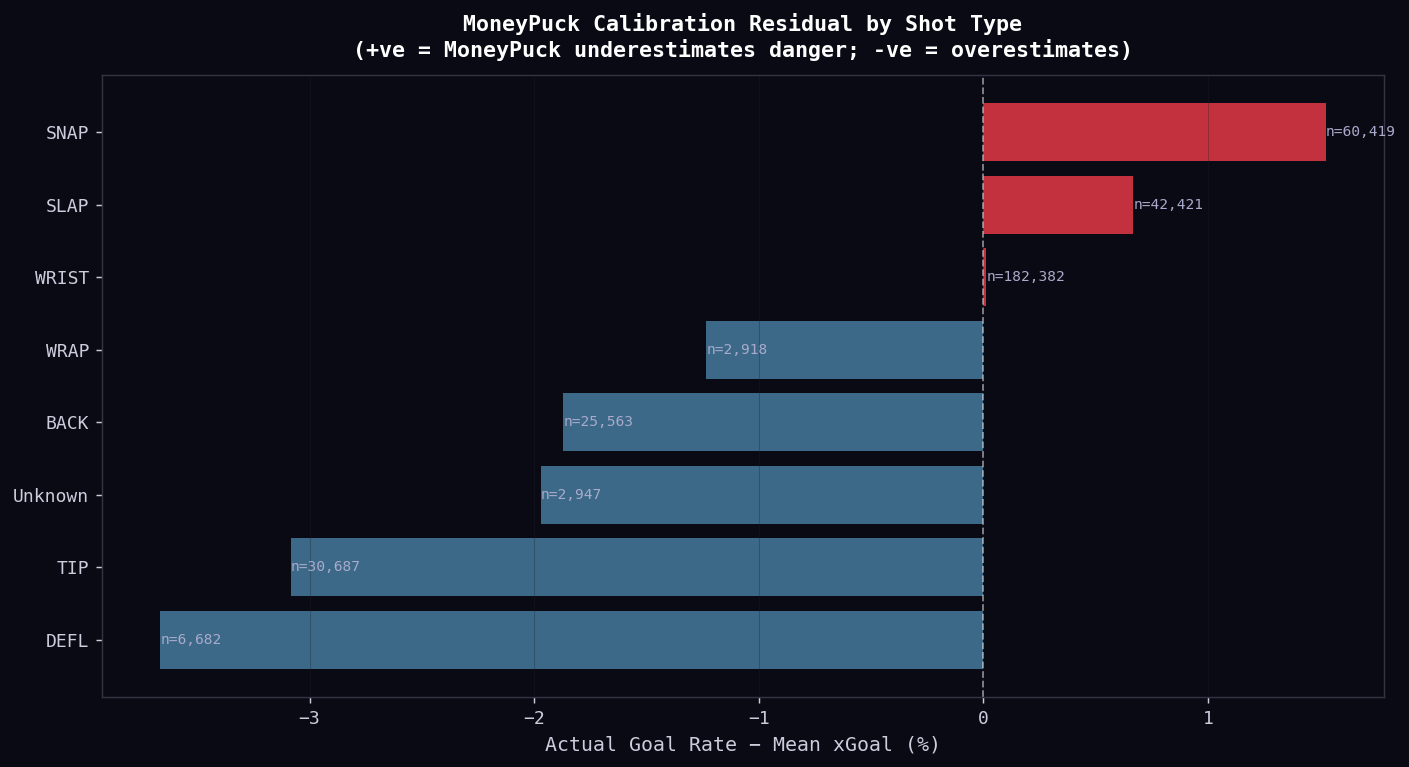

           shots  actual_rate  mean_xg  residual
shotType                                        
BACK       25563       0.0841   0.1028   -0.0187
DEFL        6682       0.0956   0.1323   -0.0367
SLAP       42421       0.0502   0.0435    0.0067
SNAP       60419       0.0891   0.0738    0.0153
TIP        30687       0.0856   0.1164   -0.0308
Unknown     2947       0.1527   0.1724   -0.0197
WRAP        2918       0.0569   0.0692   -0.0123
WRIST     182382       0.0653   0.0652    0.0001


In [51]:
if 'xGoal' in oz.columns:
    type_calib = oz.groupby('shotType').agg(
        shots=('goal', 'count'),
        actual_rate=('goal', 'mean'),
        mean_xg=('xGoal', 'mean')
    ).assign(residual=lambda d: d['actual_rate'] - d['mean_xg'])

    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('#0a0a14')
    ax.set_facecolor('#0a0a14')

    types = type_calib.sort_values('residual').index
    residuals = type_calib.loc[types, 'residual']
    bar_colors = [GOAL_COLOR if r > 0 else NOGOAL_COLOR for r in residuals]

    ax.barh(types, residuals * 100, color=bar_colors, alpha=0.85)
    ax.axvline(0, color='white', lw=1, linestyle='--', alpha=0.5)
    ax.set_xlabel('Actual Goal Rate − Mean xGoal (%)', fontsize=11)
    ax.set_title('MoneyPuck Calibration Residual by Shot Type\n'
                 '(+ve = MoneyPuck underestimates danger; -ve = overestimates)',
                 color='white', fontsize=12, fontweight='bold', pad=10)
    ax.grid(axis='x', alpha=0.3)

    # Annotate shot counts
    for i, t in enumerate(types):
        ax.text(residuals[t] * 100 + 0.001, i,
                f'n={type_calib.loc[t,"shots"]:,}',
                va='center', fontsize=8, color='#aaaacc')

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}07_calibration_by_type.png', bbox_inches='tight',
                facecolor='#0a0a14', dpi=150)
    plt.show()

    print(type_calib.round(4).to_string())

MoneyPuck overestimates deflections and tips by 3–4pp overall, and by 15–18pp specifically in the high xG range (0.25–0.45). These shot types are location-dangerous but goalie-readable. The model appears to treat them like wrist shots from the same location when they're fundamentally different in terms of conversion.

Snap shots are consistently underestimated — they're fast-release, harder to track, and convert better than MoneyPuck expects.

## 11. WPG Jets Deep Dive

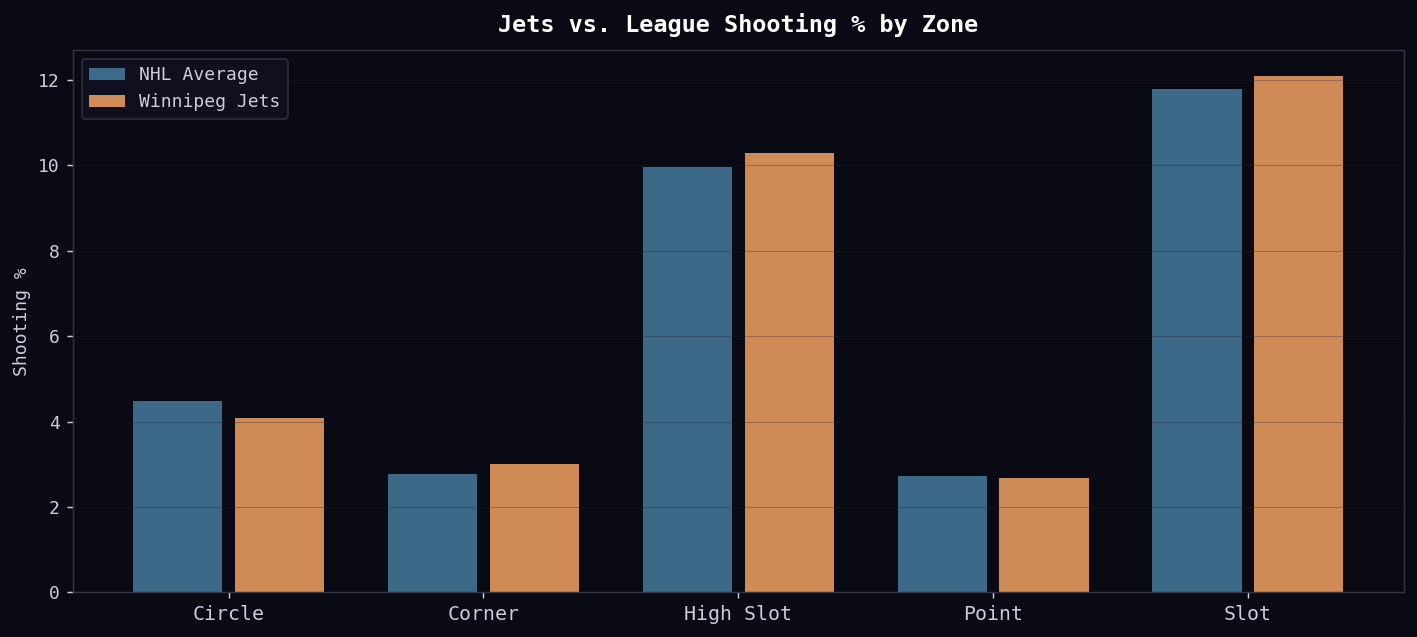

Jets vs. League Gap (pp = Jets outperforming):
           league_pct  wpg_pct   gap
zone                                
Circle           4.47     4.08 -0.39
Corner           2.78     3.01  0.23
High Slot        9.95    10.29  0.34
Point            2.73     2.68 -0.06
Slot            11.78    12.10  0.31


In [52]:
wpg = oz[oz['teamCode'] == 'WPG'].copy() if 'teamCode' in oz.columns else None

if wpg is not None and len(wpg) > 0:
    league_zone = oz.groupby('zone')['goal'].mean().rename('league_pct')
    wpg_zone    = wpg.groupby('zone')['goal'].mean().rename('wpg_pct')

    comparison = pd.concat([league_zone, wpg_zone], axis=1).dropna()
    comparison['gap'] = comparison['wpg_pct'] - comparison['league_pct']

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor('#0a0a14')
    ax.set_facecolor('#0a0a14')

    x = np.arange(len(comparison))
    ax.bar(x - 0.2, comparison['league_pct'] * 100,
           width=0.35, color=NOGOAL_COLOR, alpha=0.85, label='NHL Average')
    ax.bar(x + 0.2, comparison['wpg_pct'] * 100,
           width=0.35, color=ACCENT, alpha=0.85, label='Winnipeg Jets')

    ax.set_xticks(x)
    ax.set_xticklabels(comparison.index, fontsize=11)
    ax.set_ylabel('Shooting %')
    ax.set_title('Jets vs. League Shooting % by Zone',
                 color='white', fontsize=13, fontweight='bold', pad=10)
    ax.legend(facecolor='#111122', edgecolor='#333344')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}08_jets_comparison.png', bbox_inches='tight',
                facecolor='#0a0a14', dpi=150)
    plt.show()

    print('Jets vs. League Gap (pp = Jets outperforming):')
    print((comparison * 100).round(2).to_string())
else:
    print('teamCode column not found or no WPG rows — check column name in data dictionary')

The Jets are essentially league average everywhere. The largest gap is Circle at -0.39pp, which is tiny. No zone shows a meaningful structural advantage or disadvantage.This is actually an interesting finding in itself — it means the Jets' shot selection mirrors league norms closely. They're not doing anything unusually right or wrong in terms of where they shoot from.

The Jets story isn't about zone selection — it's about shot quality within zones. The more interesting Jets question is:

In [53]:
# Do the Jets generate better or worse xG per shot than the league average?
print("Mean xG per shot — Jets vs League:")
print(oz.groupby(oz['teamCode'] == 'WPG')['xGoal'].mean().rename({False: 'League', True: 'Jets'}).round(4))

# And by zone
print("\nMean xG per shot by zone — Jets vs League:")
league_xg = oz.groupby('zone')['xGoal'].mean().rename('league_xg')
wpg_xg = oz[oz['teamCode'] == 'WPG'].groupby('zone')['xGoal'].mean().rename('wpg_xg')
print(pd.concat([league_xg, wpg_xg], axis=1).assign(
    gap=lambda d: d['wpg_xg'] - d['league_xg']
).round(4).to_string())

Mean xG per shot — Jets vs League:
teamCode
League    0.0735
Jets      0.0728
Name: xGoal, dtype: float64

Mean xG per shot by zone — Jets vs League:
           league_xg  wpg_xg     gap
zone                                
Circle        0.0375  0.0366 -0.0009
Corner        0.0276  0.0236 -0.0040
High Slot     0.0828  0.0815 -0.0014
Point         0.0263  0.0245 -0.0019
Slot          0.1300  0.1303  0.0003


## 12. EDA Summary & Feature Engineering Flags

Key takeaways from the EDA.

In [55]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║               EDA SUMMARY — KEY FINDINGS                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. CLASS IMBALANCE                                              ║
║     7.0% goal rate (regulation). Use log-loss / Brier,          ║
║     NOT accuracy. Consider class_weight='balanced'.              ║
║                                                                  ║
║  2. GAME CONTEXT MATTERS                                         ║
║     3v3 OT: 13.8% goal rate vs 7.0% regulation (+6.8pp).        ║
║     MoneyPuck underestimates 3v3 OT by 4.4pp (9.4% xG           ║
║     vs 13.8% actual). Add game_context as a feature.            ║
║                                                                  ║
║  3. ZONE INEFFICIENCY                                            ║
║     Point shots = 29.6% of attempts, 2.7% conversion.           ║
║     Slot = 38.2% of attempts, 11.7% conversion.                 ║
║     Teams fire a third of shots from the worst zone.            ║
║                                                                  ║
║  4. ANGLE IS WEAK ALONE — INTERACTION REQUIRED                   ║
║     0° shots convert at 10.7% from 27ft mean distance.          ║
║     Angle has flat signal across 0-70°; only works paired        ║
║     with distance. Add dist_sq + angle_x_dist features.         ║
║                                                                  ║
║  5. MONEYPUCK MISCALIBRATION — CORE FINDING                      ║
║     Overestimates xG by 10-11pp in the 0.25-0.45 band.          ║
║     90% of affected shots are Slot (18.9% actual vs 31.5%).     ║
║     Worst offenders: DEFL -17.9pp, TIP -15.1pp, WRAP -21pp.    ║
║     WRIST perfectly calibrated (+0.01pp, n=182,382).            ║
║     SNAP underestimated by +1.53pp — fast release, hard         ║
║     to track.                                                    ║
║                                                                  ║
║  6. JETS FINDING                                                 ║
║     League-average shot quality in all zones (0.0728 vs         ║
║     0.0735 xG/shot). Jets over/underperformance is              ║
║     attributable to finishing or goaltending, not               ║
║     shot selection. Test in notebook 05.                        ║
║                                                                  ║
║  7. NEXT NOTEBOOK (02_feature_engineering.ipynb)                 ║
║     Build: dist, angle, dist_sq, angle_x_dist, zone,            ║
║            shot_type dummies, game_context, shooterLeftRight,   ║
║            shotRebound, shotRush, offWing, manpower situation   ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║               EDA SUMMARY — KEY FINDINGS                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. CLASS IMBALANCE                                              ║
║     7.0% goal rate (regulation). Use log-loss / Brier,          ║
║     NOT accuracy. Consider class_weight='balanced'.              ║
║                                                                  ║
║  2. GAME CONTEXT MATTERS                                         ║
║     3v3 OT: 13.8% goal rate vs 7.0% regulation (+6.8pp).        ║
║     MoneyPuck underestimates 3v3 OT by 4.4pp (9.4% xG           ║
║     vs 13.8% actual). Add game_context as a feature.            ║
║                                                                  ║
║  3. ZONE INEFFICIENCY                                            ║
║     Point shots = 29.6% of attempts,

In [60]:
from config import OZ_CLEAN_PARQUET
#%pip install fastparquet
oz.to_parquet(OZ_CLEAN_PARQUET, engine='fastparquet', index=False)